# Laboratorio 1: regresión lineal

#### _Integrantes: Pedro Pablo Sanín (202221527)_

## 1. Exploración de datos

### 1.1 Importación de librerías

Inicialmente importamos todas las librerías que necesitaremos para el modelo.

In [82]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn
%pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    FunctionTransformer,
 )
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### 1.2 Carga del dataset

A continuación cargamos el dataset con los datos metereologicos. Tenemos dos conjuntos de datos: Datos Lab 1.csv para el entrenamiento del modelo, y Datos Test Lab 1.csv para las pruebas del modelo.

In [84]:
data_meteo = pd.read_csv("./data/Datos Lab 1.csv") #cargamos el dataset Datos Lab 1.csv
data = data_meteo.copy() #hacemos una copia del dataset para no modificar el original

In [85]:
print("Número de filas y columnas:", data_meteo.shape)
data_meteo.head()

Número de filas y columnas: (2576, 27)


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [86]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

### 1.3 Exploración del conjunto de datos

A continuación exploraremos el conjunto de datos. Para ello, cargaremos el diccionario de datos.

In [87]:
diccionario_datos = pd.read_excel("./data/Diccionario de datos.xlsx") #cargamos el diccionario de datos
pd.set_option('display.max_colwidth', None)
diccionario_datos

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


A continuación describiremos el tipo estadístico de cada columna y su rango válido.



| Variable | Tipo de dato | Clasificación estadística | Rango de validez | Consideraciones |
| -------- | -------- | -------- | -------- | -------- |
| *fecha*    | fecha     | Cualitativa ordinal     | 01.01.2003 - 22.07.2026     | Debe verificarse la consistencia de la cadena en días, meses y años     |
| *presion_media*    | numérico     | Cuantitativa continua     | ≥ 0     | Ninguna     |
| *presion_min*    | numérico     | Cuantitativa continua     | ≥ 0     | Debe ser ≤ presion_media     |
| *presion_max*    | numérico     | Cuantitativa continua     | ≥ 0     | Debe ser ≥ presion_media     |
| *presion_desv*    | numérico     | Cuantitativa continua     | ≥ 0     | Al ser una desviación típica, no puede ser negativa     |
| *humedad_media*    | numérico     | Cuantitativa continua     | [0, 100]     | Es un porcentaje, no debe exceder 100     |
| *humedad_min*    | numérico     | Cuantitativa continua     | [0, 100]     | Debe ser ≤ humedad_media     |
| *humedad_max*    | numérico     | Cuantitativa continua     | [0, 100]     | Debe ser ≥ humedad_media     |
| *humedad_desv*    | numérico     | Cuantitativa continua     | ≥ 0     | No puede ser negativa     |
| *viento_media*    | numérico     | Cuantitativa continua     | ≥ 0     | La velocidad no puede ser negativa     |
| *viento_min*    | numérico     | Cuantitativa continua     | ≥ 0     | Debe ser ≤ viento_media     |
| *viento_max*    | numérico     | Cuantitativa continua     | ≥ 0     | Debe ser ≥ viento_media     |
| *viento_desv*    | numérico     | Cuantitativa continua     | ≥ 0     | No puede ser negativa     |
| *rafaga_media*    | numérico     | Cuantitativa continua     | ≥ 0     | Usualmente ≥ viento_media     |
| *rafaga_min*    | numérico     | Cuantitativa continua     | ≥ 0     | Debe ser ≤ rafaga_media     |
| *rafaga_max*    | numérico     | Cuantitativa continua     | ≥ 0     | Debe ser ≥ rafaga_media y ≥ viento_max     |
| *rafaga_desv*    | numérico     | Cuantitativa continua     | ≥ 0     | No puede ser negativa     |
| *viento_norte*    | numérico     | Cuantitativa continua     | Sin límite fijo (puede ser negativo)     | Signo indica sentido norte (+) o sur (−)     |
| *viento_este*    | numérico     | Cuantitativa continua     | Sin límite fijo (puede ser negativo)     | Signo indica sentido este (+) u oeste (−)     |
| *direccion_viento*    | numérico      | Cuantitativa continua     | [0, 360)     | Variable circular; 0° y 360° representan el mismo punto     |
| *registros_del_dia*    | numérico (entero)     | Cuantitativa discreta     | [1, 144]     | Un día completo corresponde a 144 mediciones de 10 minutos     |
| *anio*    | numérico (entero)     | Cuantitativa discreta     | 2003 - 2026     | Debe coincidir con el año contenido en la variable fecha     |
| *dia_del_anio*    | numérico (entero)     | Cuantitativa discreta     | [1, 366]     | El valor máximo depende de si el año es bisiesto     |
| *estacion_anio*    | categórico     | Cualitativa ordinal     | {invierno, primavera, verano, otoño}     | Sigue el orden cíclico natural de las estaciones     |
| *mes*    | categórico     | Cualitativa ordinal     | {enero, febrero, ..., diciembre}     | Debe coincidir con el mes contenido en la variable fecha     |
| *sector_viento*    | categórico     | Cualitativa nominal     | {N, NE, E, SE, S, SO, O, NO}     | No hay jerarquía entre categorías; debe ser consistente con direccion_viento     |
| *temp_max_manana*    | numérico     | Cuantitativa continua     | Rango razonable según clima local (p. ej. -20°C a 55°C)     | Variable objetivo; corresponde al día siguiente     |

Ahora, veremos una idea general de las columnas numéricas de los datos.

In [88]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Ahora haremos lo mismo para las variables categóricas

In [89]:
data.describe(include="object")

/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_39369/460854327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object")


,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2009-01-22,primavera,May,SO
freq,2,517,127,695


Podemos ver a simple vista algunos problemas en las variables:

| Variable  | Problemas  |
|---|---|
| presion_media  | El valor máximo es demasiado alto, probablemente porque tiene un 9 de más en el primer dígito |
|  humedad_min |  El valor máximo es mayor a 100% |
|  rafaga_min |  El valor mínimo es negativo |
|  rafaga_desv |  El valor mínimo es negativo |
| estacion_anio | Hay 28 valores diferentes, cuando debería haber 4 |
| mes | Hay 61 valores diferentes, cuando debería haber 12 |
| sector_viento | Hay 33 valores diferentes cuando debería haber 8 (N, NE, E, SE, S, SO, O, NO)


### 1.4 Limpieza inicial de los datos y consistencia.

Ahora, haremos una primera limpieza de los datos. Para esto revisaremos: normalización de variables categóricas, unicidad de los datos, los valores claramente erróneos. 

#### 1.4.1 Consistencia de los datos

Antes de comenzar, queremos normalizar las etiquetas de las variables categóricas para tener el número correcto de categorías. Como vimos anteriormente, tenemos muchas mas categorías de las que deberíamos en las tres variables categóricas.

In [90]:
print(f"Valores únicos en la columna 'mes': {data['mes'].unique()}")
print(f"Valores únicos en la columna 'sector_viento': {data['sector_viento'].unique()}")
print(f"Valores únicos en la columna 'estacion_anio': {data['estacion_anio'].unique()}")

Valores únicos en la columna 'mes': <StringArray>
[   'January',       'JULY',    'JANUARY',        'May',      'Enero',
          nan,       'JUNE',        'Sep',      'April',  'SEPTEMBER',
  'noviembre',    'octubre',       'Sept',   'november',      'april',
      'julio',   'February',      'APRIL',        'Aug',    'febrero',
 'septiembre',        'Mar',        'Nov',      'MARCH',   'february',
   'November',        'may',       'july',     'august',  'september',
       'July',      'March',    'October',      'junio',    'october',
      'march',      'marzo',  'September',        'Oct',   'DECEMBER',
        'Jan',      'enero',   'NOVEMBER',   'december',        'Jul',
    'OCTOBER',        'Jun',  'diciembre',     'AUGUST',       'June',
    'january',       'june',        'Feb',     'August',   'December',
     'agosto',        'Apr',       'mayo',      'abril',   'FEBRUARY',
        'MAY',        'Dec']
Length: 62, dtype: str
Valores únicos en la columna 'sector_viento': 

En este caso, podemos ver que hay muchos valores para representar el mismo mes, sector_viento o estacion_anio. A continuación transformaremos esos valores para que sean consistentes.

In [91]:
print(f"Valores únicos en la columna 'mes' antes de la limpieza: {data['mes'].unique()}")
print("\n--------------")
data["mes"]=data["mes"].str.lower().str.strip()#convertimos los valores de la columna mes a minúsculasaugust":"agosto", "october":"octubre", "november":"noviembre", "december":"diciembre"})#reemplazamos los valores abreviados de la columna mes por los valores completos
data["mes"]=data["mes"].replace({"enero":"january", "febrero":"february", "marzo":"march", "abril":"april", "mayo":"may", "junio":"june", "julio":"july", "agosto":"august", "septiembre":"september", "octubre":"october", "noviembre":"november", "diciembre":"december", "jan":"january", "feb":"february", "mar":"march", "apr":"april", "jun":"june", "jul":"july","aug":"august","sept":"september" ,"sep":"september","oct":"october","nov":"november","dec":"december"})#reemplazamos los valores abreviados de la columna mes por los valores completos
data["mes"]=data["mes"].str.capitalize()

print(f"Valores únicos en la columna 'mes' después de la limpieza: {data['mes'].unique()}")

Valores únicos en la columna 'mes' antes de la limpieza: <StringArray>
[   'January',       'JULY',    'JANUARY',        'May',      'Enero',
          nan,       'JUNE',        'Sep',      'April',  'SEPTEMBER',
  'noviembre',    'octubre',       'Sept',   'november',      'april',
      'julio',   'February',      'APRIL',        'Aug',    'febrero',
 'septiembre',        'Mar',        'Nov',      'MARCH',   'february',
   'November',        'may',       'july',     'august',  'september',
       'July',      'March',    'October',      'junio',    'october',
      'march',      'marzo',  'September',        'Oct',   'DECEMBER',
        'Jan',      'enero',   'NOVEMBER',   'december',        'Jul',
    'OCTOBER',        'Jun',  'diciembre',     'AUGUST',       'June',
    'january',       'june',        'Feb',     'August',   'December',
     'agosto',        'Apr',       'mayo',      'abril',   'FEBRUARY',
        'MAY',        'Dec']
Length: 62, dtype: str

--------------
Valores ú

In [92]:
print(f"Valores únicos en la columna 'sector_viento' antes de la limpieza: {data['sector_viento'].unique()}")
print("\n--------------")
data["sector_viento"]=data["sector_viento"].str.lower().str.strip()#convertimos los valores de la columna sector_viento a minúsculas
data["sector_viento"]=data["sector_viento"].replace({"norte":"n", "sur":"s", "este":"e", "oeste":"w","noreste":"ne", "sureste":"se", "suroeste":"sw", "noroeste":"nw", "north":"n", "south":"s", "east":"e", "west":"w", "northeast":"ne", "southeast":"se", "northwest":"nw", "southwest":"sw", "no":"nw", "o":"w", "so":"sw"})#reemplazamos los valores abreviados de la columna sector_viento por los valores completos
data["sector_viento"]=data["sector_viento"].str.upper()

print(f"Valores únicos en la columna 'sector_viento' después de la limpieza: {data['sector_viento'].unique()}")

Valores únicos en la columna 'sector_viento' antes de la limpieza: <StringArray>
[        'S',        'NE',        'SO',         'N',     'South',   'Sureste',
         nan,  'Suroeste',   'Noreste',       'Sur',         'O',     'North',
        'so',     'Oeste',         'o',         'E', 'NORTHEAST',        'NO',
     'NORTH',        'SE',  'Noroeste', 'SOUTHWEST',      'West',         's',
      'WEST',     'SOUTH',        'ne',      'East', 'NORTHWEST',        'no',
      'EAST', 'SOUTHEAST',      'Este',     'Norte']
Length: 34, dtype: str

--------------
Valores únicos en la columna 'sector_viento' después de la limpieza: <StringArray>
['S', 'NE', 'SW', 'N', 'SE', nan, 'W', 'E', 'NW']
Length: 9, dtype: str


In [93]:
print(f"Valores únicos en la columna 'estacion_anio' antes de la limpieza: {data['estacion_anio'].unique()}")
print("\n--------------")
data["estacion_anio"]=data["estacion_anio"].str.lower().str.strip()#convertimos los valores de la columna estacion_anio a minúsculas
data["estacion_anio"]=data["estacion_anio"].replace({"primavera":"spring", "verano":"summer", "otoño":"autumn", "otono":"autumn", "invierno":"winter", "primav":"spring", "primaveraa":"spring", "berano":"summer", "fall":"autumn", "invernio":"winter", "verno":"summer"})#reemplazamos los valores abreviados de la columna estacion_anio por los valores completos
print(f"Valores únicos en la columna 'estacion_anio' después de la limpieza preliminar: {data['estacion_anio'].unique()}")
print("\n--------------")

#vea que en este caso, tenemos valores que no corresponden a ninguna estación del año, por lo que los dejaremos como nan
data.loc[~data["estacion_anio"].isin(["spring", "summer", "autumn", "winter"]), "estacion_anio"] = np.nan
data["estacion_anio"]=data["estacion_anio"].replace({"spring":"primavera","summer":"verano","autumn":"otono", "winter":"invierno"})

print(f"Valores únicos en la columna 'estacion_anio' después de la limpieza: {data['estacion_anio'].unique()}")

Valores únicos en la columna 'estacion_anio' antes de la limpieza: <StringArray>
[            'invierno',                 'East',                    nan,
 'Estacion_Desconocida',               'verano',             'Inverano',
            'invierno ',             'INVIERNO',      'VERANO_INVIERNO',
               'Verano',            'primavera',            'Primavera',
           'primaveraa',            'PRIMAVERA',               'berano',
               'VERANO',                'verno',                'otono',
               'otoño ',                 'fall',               'autumn',
                'OTONO',               'winter',             'invernio',
               'primav',               'spring',                'Otoño',
             'Invierno',               'summer']
Length: 29, dtype: str

--------------
Valores únicos en la columna 'estacion_anio' después de la limpieza preliminar: <StringArray>
[              'winter',                 'east',                    nan,
 'estac

Ahora, todos los datos de las variables categóricas son consistentes.

#### 1.4.2 Corrección de errores en las variables cualitativas.

Ahora corregiremos errores evidentes en el conjunto de variables cuantitativas. Estos errores pueden corresponder a:

1. Que la estacion o el mes no corresponda a la fecha.
2. Que el sector del viento no corresponda a la dirección del viento.

Corregiremos ambos errores.


Para corregir las inconsistencias y datos faltantes de fecha, primero llenamos los datos en lo que fecha sea nulo usando anio y dia_del_anio. Después, con todas las fechas en todas las filas, reconstruimos las columnas "fecha", "anio", "dia_del_anio", "mes", "estacion_anio".

In [94]:
#Primero convertimos la fecha a datetime

data["fecha"] = pd.to_datetime(data["fecha"], errors="coerce")

# Primero reconstruimos las filas con fecha faltante
def obtener_fecha(anio, dia_del_anio):
    """Retorna una fecha pandas datetime a partir del año y día del año."""
    if pd.isna(anio) or pd.isna(dia_del_anio):
        return pd.NaT

    return pd.Timestamp(int(anio), 1, 1) + pd.Timedelta(days=int(dia_del_anio) - 1)


mask_fecha_faltante = (
    data["fecha"].isna()
    & data["anio"].notna()
    & data["dia_del_anio"].notna()
)

for indice in data.index[mask_fecha_faltante]:
    data.loc[indice, "fecha"] = obtener_fecha(
        data.loc[indice, "anio"],
        data.loc[indice, "dia_del_anio"],
    )

print("Fechas con fecha reconstruida:", mask_fecha_faltante.sum())

Fechas con fecha reconstruida: 68


In [95]:
columnas_fecha = ["fecha", "anio", "dia_del_anio", "mes", "estacion_anio"]
faltantes_antes = data[columnas_fecha].isna().sum()

meses = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December",
}
estaciones = {
    12: "invierno", 1: "invierno", 2: "invierno",
    3: "primavera", 4: "primavera", 5: "primavera",
    6: "verano", 7: "verano", 8: "verano",
    9: "otono", 10: "otono", 11: "otono",
}

fecha_vecina = data["fecha"].ffill().bfill()
data["fecha"] = data["fecha"].fillna(fecha_vecina)

mask = data["fecha"].notna()
fechas = data.loc[mask, "fecha"]

data.loc[mask, "anio"] = fechas.dt.year
data.loc[mask, "dia_del_anio"] = fechas.dt.dayofyear
data.loc[mask, "mes"] = fechas.dt.month.map(meses)
data.loc[mask, "estacion_anio"] = fechas.dt.month.map(estaciones)

data["anio"] = data["anio"].astype("Int64")
data["dia_del_anio"] = data["dia_del_anio"].astype("Int64")
data["mes"] = data["mes"].astype("category")
data["estacion_anio"] = data["estacion_anio"].astype("category")

faltantes_despues = data[columnas_fecha].isna().sum()

print("Faltantes antes de imputar:")
print(faltantes_antes)
print("\nFaltantes después de imputar:")
print(faltantes_despues)

Faltantes antes de imputar:
fecha              4
anio              86
dia_del_anio      68
mes               88
estacion_anio    330
dtype: int64

Faltantes después de imputar:
fecha            0
anio             0
dia_del_anio     0
mes              0
estacion_anio    0
dtype: int64


Ahora corregiremos el sector de viento faltante.

In [96]:
def obtener_sector_compass(grados):
    """Devuelve el sector de la brújula correspondiente a un ángulo [0, 360)."""
    if pd.isna(grados):
        return np.nan

    if not 0 <= grados < 360:
        raise ValueError("El ángulo debe estar en el intervalo [0, 360).")

    sectores = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    indice = int((grados + 22.5) // 45) % 8

    return sectores[indice]

faltantes_viento_antes = data["sector_viento"].isna().sum()


mask = data["sector_viento"].isna() & data["direccion_viento"].notna()
sectores_imputados_viento = data.loc[mask, "direccion_viento"].apply(obtener_sector_compass)
data.loc[mask, "sector_viento"] = sectores_imputados_viento

data["sector_viento"] = data["sector_viento"].astype("category")
faltantes_viento_despues = data["sector_viento"].isna().sum()

print("Sectores faltantes antes de imputar:", faltantes_viento_antes)
print("Sectores faltantes después de imputar:", faltantes_viento_despues)

Sectores faltantes antes de imputar: 71
Sectores faltantes después de imputar: 0


#### 1.4.3 Correccion de errores en las variables cuantitativas

Ahora corregiremos errores en las variables cuantitativas. Estos errores pueden verse de la descripción de los datos, y no es posible que vengan de una toma correcta de los datos. Los errores evidentes que identificamos son:
1. presion_media tiene algunos errores de digitación, puesto que unos valores tienen dos nueves en la posicion inicial en vez de uno solo. Esto produce presiones de >9000 mbar, que no se tienen en la tierra.
2. presion_max, presion_min no siempre están en orden (o humedad, viento, ráfagas)
3. humedad_max tiene valores mayores a 100%.
4. rafaga_desv tiene valores negativos
5. rafaga_min, rafaga_media tiene valores negativos
6. Rafaga desv y viento desv tienen errores de digitacion y unos valores máximos excesivamente altos de >3000.
7. Viento norte tiene un valor mínimo excesivamente bajo (-1200), mucho mayor a la velocidad del sonido, y que no es posible enla tierra.

In [97]:
# Corrección de errores en las variables cuantitativas

# Se elimina el primer dígito de los valores anormalmente altos de presión media.
presion_media_mayor_9000 = data["presion_media"] > 9000
data.loc[presion_media_mayor_9000, "presion_media"] = (
    data.loc[presion_media_mayor_9000, "presion_media"]
    .astype(str)
    .str[1:]
    .replace("", np.nan)
    .astype(float)
)

# Se corrige la digitación de las desviaciones con valores excesivamente altos.
columnas_desviacion = ["viento_desv", "rafaga_desv"]
desviaciones_mayores_30 = data[columnas_desviacion] > 30
for columna in columnas_desviacion:
    mask = desviaciones_mayores_30[columna]
    data.loc[mask, columna] = (
        data.loc[mask, columna]
        .astype(str)
        .str[1:]
        .replace("", np.nan)
        .astype(float)
    )

# Los valores que siguen siendo excesivos después de quitar el dígito erróneo se anulan.
desviaciones_aun_excesivas = (data[columnas_desviacion] > 30).sum()
for columna in columnas_desviacion:
    data.loc[data[columna] > 30, columna] = np.nan

# Se anula el valor extremo de viento norte, conservando los valores negativos normales.
viento_norte_irreal = data["viento_norte"] < -100
data.loc[viento_norte_irreal, "viento_norte"] = np.nan

# Se intercambian presión máxima y mínima cuando están en el orden incorrecto.
orden_presion_invertido = data["presion_max"] < data["presion_min"]
data.loc[orden_presion_invertido, ["presion_max", "presion_min"]] = data.loc[
    orden_presion_invertido, ["presion_min", "presion_max"]
].to_numpy()

# Se corrige el orden de las variables de humedad antes de limitar sus valores.
columnas_humedad = ["humedad_media", "humedad_min", "humedad_max"]
orden_humedad_invertido = data["humedad_max"] < data["humedad_min"]
data.loc[orden_humedad_invertido, ["humedad_max", "humedad_min"]] = data.loc[
    orden_humedad_invertido, ["humedad_min", "humedad_max"]
].to_numpy()

# Se intercambian viento máximo y mínimo cuando están invertidos.
orden_viento_invertido = data["viento_max"] < data["viento_min"]
data.loc[orden_viento_invertido, ["viento_max", "viento_min"]] = data.loc[
    orden_viento_invertido, ["viento_min", "viento_max"]
].to_numpy()

# Se intercambian ráfaga máxima y mínima cuando están invertidas.
orden_rafaga_invertido = data["rafaga_max"] < data["rafaga_min"]
data.loc[orden_rafaga_invertido, ["rafaga_max", "rafaga_min"]] = data.loc[
    orden_rafaga_invertido, ["rafaga_min", "rafaga_max"]
].to_numpy()

# Se cuentan y se recortan los porcentajes de humedad al rango válido [0, 100].
valores_humedad_fuera_rango = (
    (data[columnas_humedad] < 0) | (data[columnas_humedad] > 100)
).sum().sum()
data[columnas_humedad] = data[columnas_humedad].clip(lower=0, upper=100)

# Las desviaciones menores entre -3 y 0 se convierten a valores absolutos.
# Los valores menores que -3 se consideran errores irrecuperables.
rafaga_desv_irreal = data["rafaga_desv"] < -3
data.loc[rafaga_desv_irreal, "rafaga_desv"] = np.nan
mask_rafaga_desv_leve = data["rafaga_desv"].between(-3, 0, inclusive="both")
data.loc[mask_rafaga_desv_leve, "rafaga_desv"] = data.loc[
    mask_rafaga_desv_leve, "rafaga_desv"
].abs()

# Los valores negativos de ráfaga media y mínima se consideran errores irrecuperables.
rafaga_media_irreal = data["rafaga_media"] < 0
rafaga_min_irreal = data["rafaga_min"] < 0
data.loc[rafaga_media_irreal, "rafaga_media"] = np.nan
data.loc[rafaga_min_irreal, "rafaga_min"] = np.nan

# Se informa cuántos registros fueron modificados por cada regla.
print("Presiones medias corregidas:", presion_media_mayor_9000.sum())
print("Desviaciones de viento corregidas:", desviaciones_mayores_30["viento_desv"].sum())
print("Desviaciones de ráfaga corregidas:", desviaciones_mayores_30["rafaga_desv"].sum())
print("Desviaciones de viento aún excesivas anuladas:", desviaciones_aun_excesivas["viento_desv"])
print("Desviaciones de ráfaga aún excesivas anuladas:", desviaciones_aun_excesivas["rafaga_desv"])
print("Viento norte excesivamente bajo anulado:", viento_norte_irreal.sum())
print("Pares de presión invertidos:", orden_presion_invertido.sum())
print("Pares de humedad invertidos:", orden_humedad_invertido.sum())
print("Pares de viento invertidos:", orden_viento_invertido.sum())
print("Pares de ráfaga invertidos:", orden_rafaga_invertido.sum())
print("Valores de humedad ajustados:", valores_humedad_fuera_rango)
print("Ráfagas desviación irrealmente negativas anuladas:", rafaga_desv_irreal.sum())
print("Ráfagas medias negativas anuladas:", rafaga_media_irreal.sum())
print("Ráfagas mínimas negativas anuladas:", rafaga_min_irreal.sum())

Presiones medias corregidas: 6
Desviaciones de viento corregidas: 258
Desviaciones de ráfaga corregidas: 1
Desviaciones de viento aún excesivas anuladas: 77
Desviaciones de ráfaga aún excesivas anuladas: 1
Viento norte excesivamente bajo anulado: 1
Pares de presión invertidos: 121
Pares de humedad invertidos: 98
Pares de viento invertidos: 120
Pares de ráfaga invertidos: 122
Valores de humedad ajustados: 23
Ráfagas desviación irrealmente negativas anuladas: 258
Ráfagas medias negativas anuladas: 1
Ráfagas mínimas negativas anuladas: 1


In [98]:
data.describe()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2576,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,...,2503.000000,2503.000000,2238.000000,2495.000000,2512.000000,2497.000000,2499.000000,2576.0,2576.0,2481.000000
mean,2012-07-01 23:14:43.229813,988.902907,986.263352,992.123625,1.752041,52.413586,43.509719,91.811586,10.606821,3.814103,...,0.857496,7.442991,1.673941,-0.627728,-0.410159,172.104573,144.090836,2012.001165,183.114519,13.863309
min,2009-01-01 00:00:00,784.115000,913.600000,951.940000,0.226900,0.004663,0.237700,33.610000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-6.797700,-3.718500,0.000000,90.000000,2009.0,1.0,-15.230000
25%,2010-10-01 18:00:00,984.239400,981.212500,987.550000,0.899050,0.869060,1.011790,89.000000,6.082100,1.655350,...,0.440000,5.151166,1.160450,-1.636350,-1.236475,91.303500,144.000000,2010.0,92.0,7.310000
50%,2012-07-05 12:00:00,989.429900,986.705000,992.320000,1.444550,68.558100,48.450000,93.700000,10.199800,2.463400,...,0.640000,7.000000,1.545250,-0.564300,-0.356000,199.568500,144.000000,2012.0,183.0,14.310000
75%,2014-04-01 06:00:00,994.381800,992.020000,997.112500,2.254800,80.562600,65.180000,96.789916,14.722200,4.880505,...,1.000000,9.242744,2.096100,0.241650,0.316275,227.101700,144.000000,2014.0,275.0,20.460000
max,2015-12-31 00:00:00,1011.653800,1010.996120,1013.940000,12.397500,100.000000,100.000000,100.000000,26.341600,24.753600,...,13.012602,23.500000,6.054800,4.809900,4.713900,359.796700,287.000000,2015.0,366.0,63.050000
std,NaN,10.134526,8.741695,7.642242,1.215931,35.975384,28.681543,7.350486,5.481338,3.307402,...,0.757871,3.101282,0.716701,1.556433,1.147218,86.102348,4.107365,2.000873,105.632014,9.296199


Podemos ver que ahora todos los datos son consistentes con las reglas del negocio, aunque puede haber outliers que evaluaremos mas adelante. Note que además, las filas que tienen temperatura_max_manana nula, deben ser eliminadas pues esta es nuestra variable objetivo, e imputarlas nos daría información infundada de su distribución o estructura de la variable, y podemos dañar la predictibilidad de nuestros modelos.

In [99]:
filas_con_objetivo_nulo = data.index[data["temp_max_manana"].isna()]
filas_eliminadas = data.loc[filas_con_objetivo_nulo].copy()

print("Filas con temp_max_manana nula:", list(filas_con_objetivo_nulo))
print("Número de filas eliminadas:", len(filas_con_objetivo_nulo))

data = data.drop(index=filas_con_objetivo_nulo).copy()

print("Nulos restantes en temp_max_manana:", data["temp_max_manana"].isna().sum())

Filas con temp_max_manana nula: [5, 15, 24, 30, 32, 70, 78, 153, 188, 201, 271, 282, 301, 314, 330, 366, 367, 370, 391, 438, 495, 538, 587, 591, 609, 613, 631, 633, 660, 728, 757, 767, 847, 884, 885, 894, 925, 927, 929, 945, 984, 988, 994, 997, 1045, 1058, 1082, 1110, 1133, 1135, 1162, 1188, 1191, 1234, 1264, 1283, 1295, 1301, 1395, 1396, 1405, 1433, 1465, 1542, 1563, 1564, 1581, 1582, 1639, 1688, 1792, 1798, 1803, 1833, 1868, 1876, 2003, 2011, 2028, 2053, 2083, 2110, 2127, 2129, 2203, 2230, 2263, 2329, 2340, 2374, 2379, 2399, 2520, 2535, 2543]
Número de filas eliminadas: 95
Nulos restantes en temp_max_manana: 0


#### 1.4.4 Eliminación de duplicados

A contiuación veremos si quedan datos duplicados después de nuestras correcciones.

In [100]:
# Detalle de los registros
dup_table = (
    data[data['fecha'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['repeticiones', 'fecha'], ascending=[False, True])
)

dup_table

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
21,2009-01-22,784.115000,971.48,983.54000,3.9853,86.731100,69.1100,97.6,9.7926,10.096920,...,-0.1899,183.9897,144.0,2009,22,invierno,January,S,5.770000,2
2563,2009-01-22,784.115000,971.48,983.54000,3.9853,86.731100,69.1100,97.6,9.7926,10.096920,...,-0.1899,183.9897,144.0,2009,22,invierno,January,S,5.770000,2
63,2009-03-05,959.860700,958.67,962.54000,0.8964,94.294400,86.0000,97.8,2.8296,1.290800,...,0.1826,9.3166,144.0,2009,64,primavera,March,N,5.370000,2
2574,2009-03-05,959.860700,958.67,962.54000,0.8964,NaN,86.0000,97.8,2.8296,1.290800,...,0.1826,9.3166,144.0,2009,64,primavera,March,N,5.956009,2
121,2009-05-02,998.118900,995.99,999.41000,0.9205,77.500000,51.0900,99.6,18.9020,1.844400,...,0.4668,23.7431,144.0,2009,122,primavera,May,NE,20.890000,2
2568,2009-05-02,998.855231,995.99,999.41000,0.9205,77.500000,51.0900,99.6,18.9020,1.844400,...,0.4668,23.7431,144.0,2009,122,primavera,May,NE,20.890000,2
341,2009-12-08,983.849000,979.45,991.40000,3.7836,0.877951,0.8010,96.8,5.9641,4.534920,...,-0.8314,233.2095,144.0,2009,342,invierno,December,SW,7.120000,2
2575,2009-12-08,983.849000,979.45,991.40000,3.7836,1.021309,0.8010,96.8,5.9641,4.534920,...,NaN,233.2095,144.0,2009,342,invierno,December,SW,7.120000,2
590,2010-08-14,990.482800,989.22,991.29000,0.4346,84.386400,65.1200,95.7,9.4681,1.708600,...,0.6511,39.5952,144.0,2010,226,verano,August,NE,19.500000,2
2566,2010-08-14,991.272748,989.22,991.29000,0.4346,84.386400,65.1200,95.7,9.4681,1.708600,...,0.6511,39.5952,144.0,2010,226,verano,August,NE,19.500000,2


Para solucionar este problema, conservaremos el dato que tiene menos columnas nulas.

In [101]:
data["_nulos"] = data.isna().sum()

data = (
    data.sort_values("_nulos")
        .drop_duplicates(subset="fecha", keep="first")
        .drop(columns="_nulos")
)

dup_table = data[data["fecha"].duplicated(keep=False)]
print("Numero de fechas repetidas: ", len(dup_table))
print("Numero de duplicados exactos:", int(data.duplicated(keep=False).sum()))
print("Número de filas: ", len(data))
data.describe()

Numero de fechas repetidas:  0
Numero de duplicados exactos: 0
Número de filas:  2457


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2457,2386.000000,2389.000000,2397.000000,2378.000000,2386.000000,2379.000000,2373.000000,2398.000000,2374.000000,...,2387.000000,2386.000000,2141.000000,2379.000000,2398.000000,2382.000000,2383.000000,2457.0,2457.0,2457.000000
mean,2012-07-05 10:49:22.637362,988.990312,986.245586,992.078905,1.748167,52.265544,43.446200,91.811351,10.650256,3.804830,...,0.856063,7.442758,1.676100,-0.627016,-0.410451,172.230941,144.095258,2012.010582,183.157102,13.822540
min,2009-01-01 00:00:00,784.115000,913.600000,951.940000,0.226900,0.004663,0.237700,33.610000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-6.797700,-3.718500,0.000000,90.000000,2009.0,1.0,-15.230000
25%,2010-10-05 00:00:00,984.270000,981.270000,987.510000,0.896550,0.868128,1.023196,88.900000,6.129050,1.654850,...,0.440000,5.148059,1.164100,-1.644650,-1.234925,91.445450,144.000000,2010.0,92.0,7.340000
50%,2012-07-09 00:00:00,989.391400,986.700000,992.320000,1.443950,68.382050,48.380000,93.700000,10.246350,2.462500,...,0.640000,7.000000,1.545700,-0.556400,-0.363000,199.829200,144.000000,2012.0,183.0,14.370000
75%,2014-04-07 00:00:00,994.351150,992.000000,997.040000,2.254800,80.361700,64.930000,96.700000,14.754700,4.888360,...,1.000000,9.244116,2.098700,0.245150,0.312900,226.886125,144.000000,2014.0,274.0,20.450000
max,2015-12-31 00:00:00,1011.653800,1010.996120,1013.940000,12.397500,100.000000,100.000000,100.000000,26.341600,24.428880,...,13.012602,23.500000,6.054800,4.809900,4.713900,359.796700,287.000000,2015.0,366.0,63.050000
std,NaN,9.169840,8.731234,7.600512,1.204375,35.950630,28.658272,7.306758,5.492360,3.279228,...,0.758836,3.102982,0.715552,1.553662,1.145092,86.345078,4.206138,2.002414,105.213416,9.150335


### 1.5 Conclusiones sobre la exploración de los datos

A continuación veremos las distribuciones de cada una de las columnas. Podemos ver que, si bien hay outliers, todas nuestras columnas tienen distribuciones razonables posibles por lo que se vería en la naturaleza. Por lo que ahora podemos empezar con el proceso de machine learning.

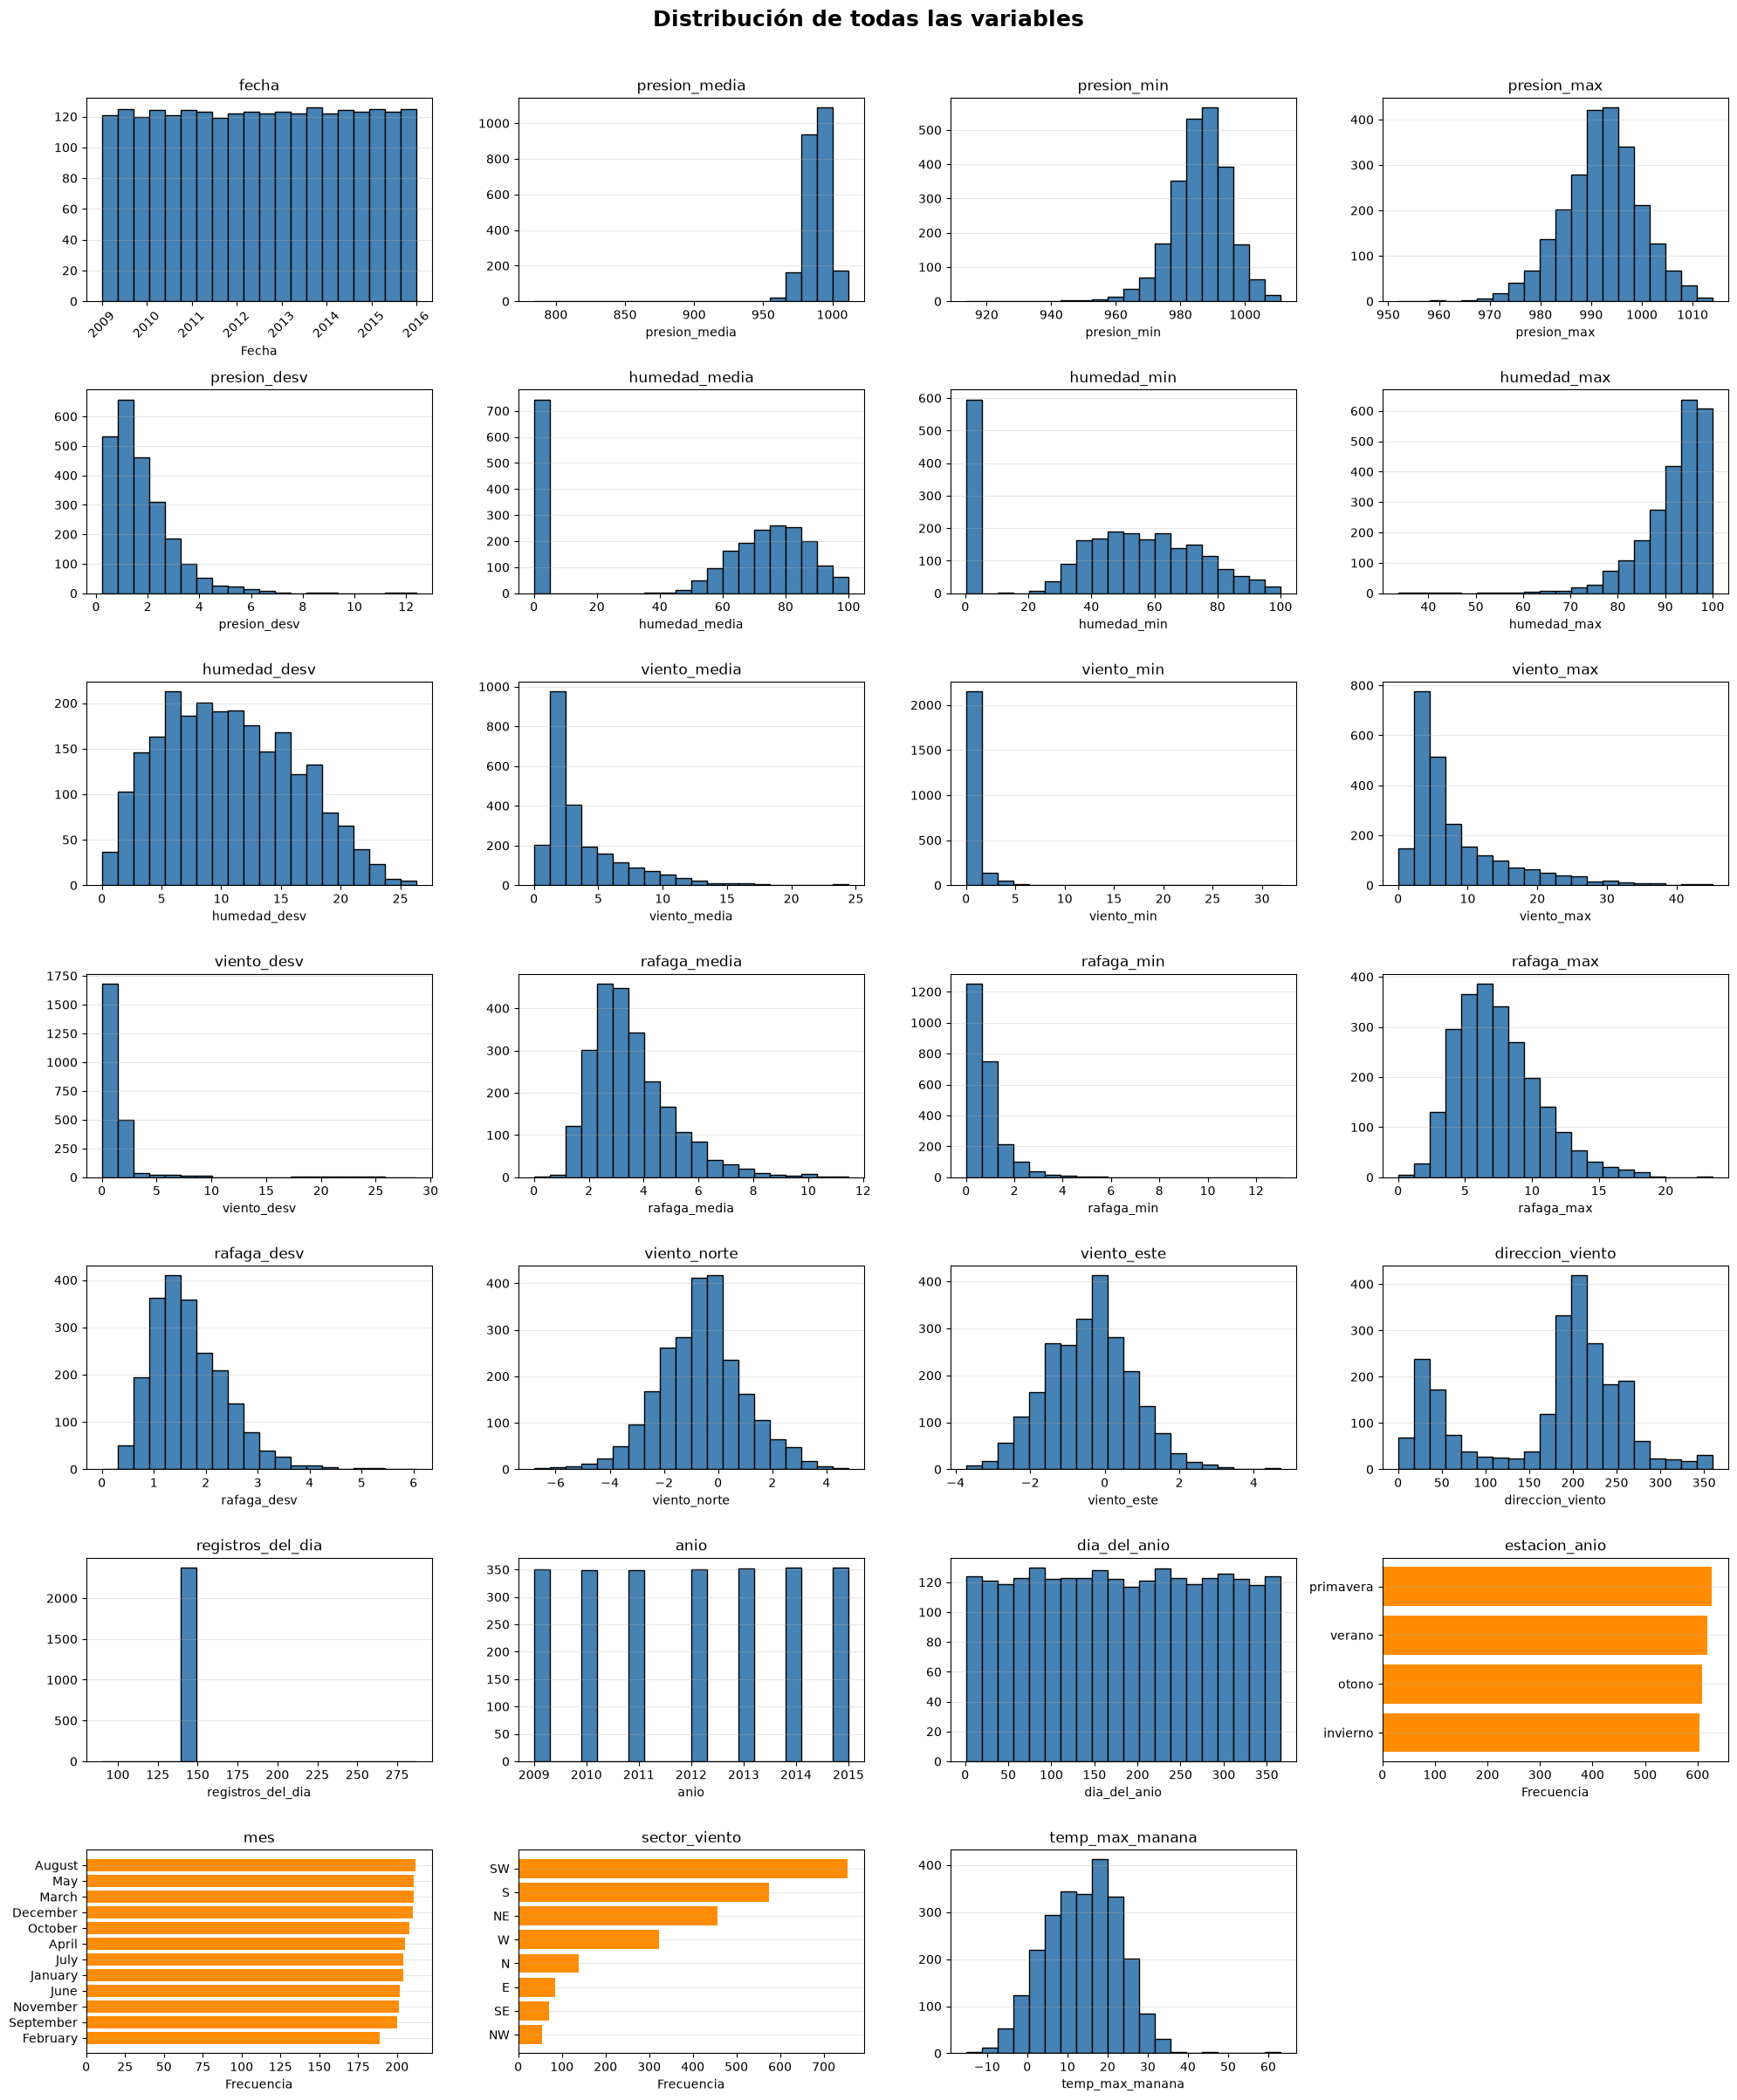

In [102]:
# Copia para no modificar el dataset original
datos_graficos = data.copy()

# Convertimos la fecha a formato datetime
if "fecha" in datos_graficos.columns:
    datos_graficos["fecha"] = pd.to_datetime(
        datos_graficos["fecha"], errors="coerce"
    )

n_columnas = 4
n_filas = int(np.ceil(len(datos_graficos.columns) / n_columnas))

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(20, n_filas * 3.5)
)

axes = np.array(axes).ravel()

for ax, columna in zip(axes, datos_graficos.columns):
    serie = datos_graficos[columna].dropna()

    if columna == "fecha":
        ax.hist(serie, bins=20, color="steelblue", edgecolor="black")
        ax.set_xlabel("Fecha")
        ax.tick_params(axis="x", rotation=45)

    elif pd.api.types.is_numeric_dtype(serie):
        ax.hist(serie, bins=20, color="steelblue", edgecolor="black")
        ax.set_xlabel(columna)

    else:
        frecuencias = (
            serie.astype(str)
            .value_counts()
            .head(15)
            .sort_values(ascending=True)
        )
        ax.barh(
            frecuencias.index,
            frecuencias.values,
            color="darkorange"
        )
        ax.set_xlabel("Frecuencia")

    ax.set_title(columna)
    ax.grid(axis="y", alpha=0.3)

# Ocultar subgráficos sobrantes
for ax in axes[len(datos_graficos.columns):]:
    ax.set_visible(False)

fig.suptitle(
    "Distribución de todas las variables",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 2. Construcción de modelos de regresión lineal

A continuación comenzaremos a construir los modelos de regresión lineal sobre los datos. Para empezar, haremos la partición de nuestro conjunto de datos.

### 2.1 Train-test split

Como los datos son meteorológicos y tienen una dimensión temporal, ordenamos las observaciones por fecha y usamos las primeras fechas para entrenamiento y las últimas para prueba. Así evaluamos el escenario real de predecir días futuros y evitamos que observaciones cercanas del mismo periodo aparezcan en ambos conjuntos.

In [103]:
target = "temp_max_manana"
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 2.2 Primer modelo de regresión

Vemos que ya hemos corregido los erroes del conjunto de datos, por lo que ahora debemos imputar las variables y transformarlas para entrenar el modelo.

Primero, eliminaremos las columnas que no consideramos predictivas o no permiten una generalización de la temperatura: fecha, registros_del_dia, anio. Después imputaremos los datos faltantes. Finalmente, transformaremos las variables para entrenar el modelo.

Este primer modelo será extremadamente sencillo y solamente queremos obtener unos coeficientes de regresión. Por ahora, no haremos ningún escalamiento especial con las variables y tampoco nos preocuparemos por las correlaciones entre columnas.

#### 2.2.1 Preprocesamiento de los datos

In [104]:
cols_to_drop =["fecha","registros_del_dia", "anio"]

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

In [105]:
numeric_features = [
    col for col in X_train.columns
    if col not in ["fecha", "anio", "registros_del_dia"]
    and pd.api.types.is_numeric_dtype(X_train[col])
]

categorical_features = [
    col for col in X_train.columns
    if col not in ["fecha", "anio", "registros_del_dia"]
    and not pd.api.types.is_numeric_dtype(X_train[col])
]

print(numeric_features)
print(categorical_features)

['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'dia_del_anio']
['estacion_anio', 'mes', 'sector_viento']


Ahora, crearemos un transformador para las variables numéricas. Este transformador imputará las entradas faltantes con la mediana (pues puede verse que hay variables con outliers).

In [106]:
numeric_transformer_1 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

Ahora, crearemos un transformador para las variables categóricas. Usaremos one-hot encoding para cada una. Como estas variables no son nulas pues las hemos imputado anteriormente, no haremos ninguna imputación.

In [107]:
categorical_transformer_1 = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

Ahora crearemos el pipeline

In [108]:
preprocessor_1 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_1, numeric_features),
        ("cat", categorical_transformer_1, categorical_features),
    ]
)

pipeline_regression_1 = pipeline_regresion = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocesamiento", preprocessor_1),
])


Ahora, visualizamos nuestro pipeline

In [109]:
from sklearn import set_config
set_config(display="diagram")
pipeline_regresion

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('preprocesamiento', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x151a9fec0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDicti

Finalmente aplicamos el procesamiento a X_train y transformamos de nuevo a un dataframe, pues el pipeline ha transformado el conjunto en un array.

In [110]:
Xt_train = pipeline_regresion.fit_transform(X_train)

feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names,
    index=X_train.index
)

In [111]:
Xt_train_df

,num__presion_media,num__presion_min,num__presion_max,num__presion_desv,num__humedad_media,num__humedad_min,num__humedad_max,num__humedad_desv,num__viento_media,num__viento_min,...,cat__mes_October,cat__mes_September,cat__sector_viento_E,cat__sector_viento_N,cat__sector_viento_NE,cat__sector_viento_NW,cat__sector_viento_S,cat__sector_viento_SE,cat__sector_viento_SW,cat__sector_viento_W
1102,0.032005,0.116738,0.294610,-0.241036,-1.440781,-1.494054,-0.203088,-1.434354,-0.412207,0.220358,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
202,-0.610094,-0.558688,-0.805526,-0.671513,0.449191,0.122317,0.401813,0.839728,-0.326465,-0.398843,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
302,1.394756,1.613723,1.475600,-0.818617,1.031342,1.153128,0.855489,-0.777529,1.668175,0.955939,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
182,0.274902,0.314649,0.203153,-0.083431,0.763220,0.324174,0.896732,0.730094,-0.624896,-0.548048,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1367,0.125608,0.191530,0.171342,-0.271955,-1.443561,-1.506138,0.759255,1.358579,-0.607984,-0.354081,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1711,0.180635,0.358373,-0.053987,-0.910578,0.689944,0.706714,0.223092,-0.294386,-0.748697,-0.451064,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1146,1.479390,1.716130,1.764551,-0.540140,-1.442597,0.478037,-0.326818,-0.090868,-0.408750,-0.301859,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1182,1.137613,0.938296,1.482227,0.975586,0.217203,-0.427848,1.082118,2.143224,0.840940,0.177089,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1353,0.088017,-0.051255,0.103743,0.352024,0.524296,0.379932,-0.917972,-0.139813,-0.537815,-0.249638,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#### 2.2.2 Entrenamiento del modelo de regresión

Ahora si, vamos a entrenar nuestro modelo de regresión lineal

In [112]:
Modelo_1 = LinearRegression()

In [113]:
Modelo_1.fit(Xt_train_df, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](44,)","[ 0.09,-0.44, 0.91,..., 1.21,-0.66,-0.99]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](44,)","['num__presion_media','num__presion_min','num__presion_max',..., 'cat__sector_viento_SE','cat__sector_viento_SW','cat__sector_viento_W']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.83
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,44
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(38)


A continuacion mostraremos los coeficientes calculados por el modelo inicial

In [114]:
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": Modelo_1.coef_
})
coef_df

,Variable,Coeficiente
0,presion_media,0.088523
1,presion_min,-0.443780
2,presion_max,0.912794
3,presion_desv,-0.592681
4,humedad_media,-0.218262
5,humedad_min,0.233594
6,humedad_max,-0.408683
7,humedad_desv,1.398479
8,viento_media,0.022801
9,viento_min,-0.284858


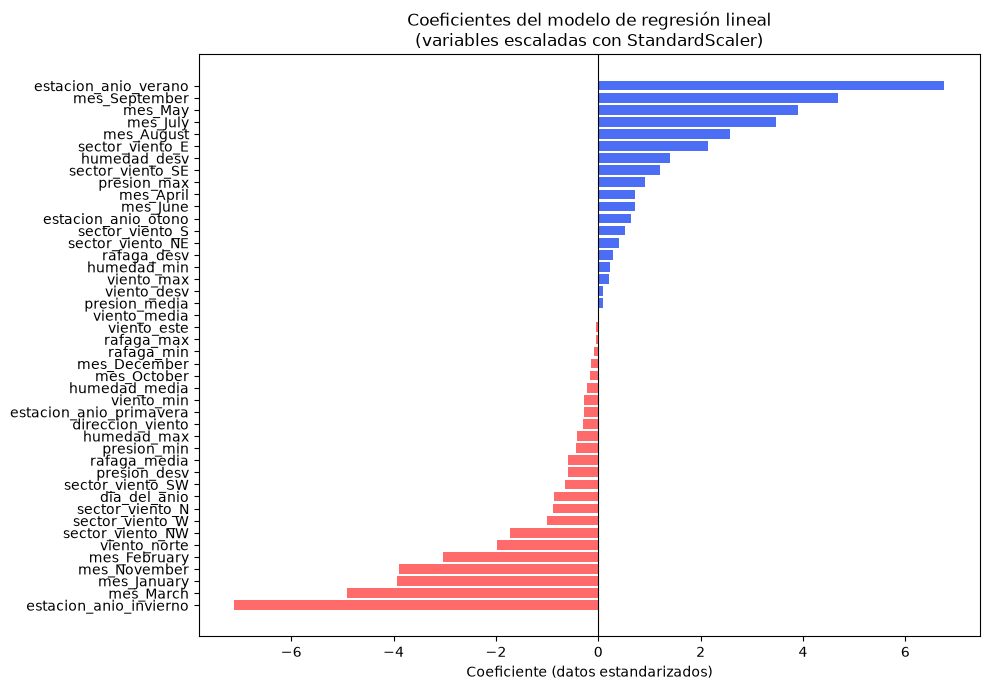

 Azul = efecto positivo en el precio  |   Rojo = efecto negativo
   Recuerda: los coeficientes son comparables entre sí porque las variables están estandarizadas.


In [115]:

coef_sorted = coef_df.sort_values('Coeficiente')
colors = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in coef_sorted['Coeficiente']]

plt.figure(figsize=(10, 7))
plt.barh(coef_sorted['Variable'], coef_sorted['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (datos estandarizados)')
plt.title('Coeficientes del modelo de regresión lineal\n(variables escaladas con StandardScaler)')
plt.tight_layout()
plt.show()
print(" Azul = efecto positivo en el precio  |   Rojo = efecto negativo")
print("   Recuerda: los coeficientes son comparables entre sí porque las variables están estandarizadas.")

Ahora, daremos las predicciones del modelo sobre el conjunto de entrenamiento.

In [116]:
y_train_pred = Modelo_1.predict(Xt_train_df)

#### 2.2.3 Métricas del modelo entrenado en los datos de entrenamiento

A continuación calcularemos las métricas del modelo entrenado. Las métricas que usaremos son: R^2, RMSE y MAE.

In [117]:
# Transformamos el conjunto de prueba con el pipeline ya ajustado al entrenamiento.
Xt_train = pipeline_regresion.transform(X_train)
feature_names_train = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names_train,
    index=X_train.index,
)

y_train_pred = Modelo_1.predict(Xt_train_df)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
desviacion_train = y_train.std()
error_relativo = mae_train / desviacion_train

metricas_train = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_train, rmse_train, mae_train],
    }
)
metricas_train

,Métrica,Valor
0,R²,0.773328
1,RMSE,4.311253
2,MAE,3.376462


#### 2.2.4 Métricas del modelo entrenado en los datos de validación

Ahora, exploraremos como se comporta el modelo para los datos de validación,

In [118]:
# Transformamos el conjunto de prueba con el pipeline ya ajustado al entrenamiento.
Xt_train = pipeline_regresion.transform(X_test)
feature_names_test = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
Xt_test_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names_test,
    index=X_test.index,
)

y_test_pred = Modelo_1.predict(Xt_test_df)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
desviacion_test = y_test.std()
error_relativo = mae_test / desviacion_test

metricas_test = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_test, rmse_test, mae_test],
    }
)
metricas_test

,Métrica,Valor
0,R²,0.607559
1,RMSE,5.954296
2,MAE,3.919093


El modelo obtiene un R² de 0.6441, por lo que explica aproximadamente el 64.41% de la variabilidad** de la temperatura máxima en el conjunto de prueba. El 35.59% restante depende de factores que el modelo no captura o de ruido en los datos.

El MAE es 3.7695 °C, lo que significa que la predicción se desvía, en promedio, cerca de 3.77 °C del valor real. El RMSE es 5.6242 °C, superior al MAE porque penaliza más los errores grandes; esto sugiere que existen algunas predicciones considerablemente alejadas del valor observado.

En conjunto, el modelo presenta una calidad moderada, pues es útil para identificar tendencias generales, pero todavía no es suficientemente preciso para predicciones puntuales de alta exactitud.

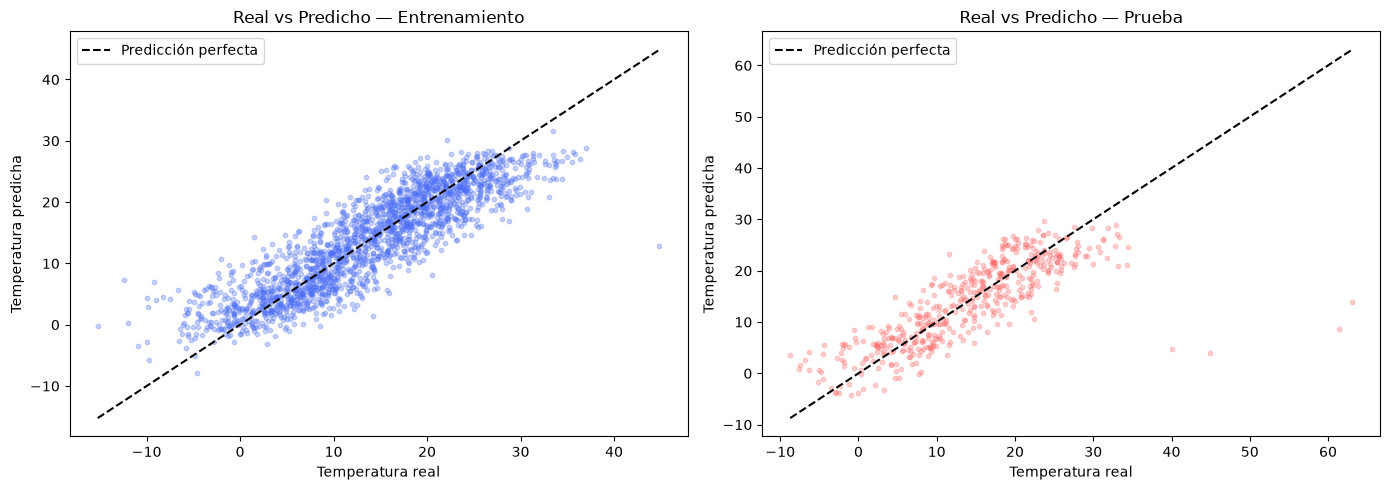

Los puntos deberían estar cerca de la línea punteada (predicción perfecta).
   La dispersión alrededor de esa línea refleja el error del modelo.


In [119]:
# Visualización: valores reales vs predichos (train y test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_real, y_pred, titulo, color in [
    (axes[0], y_train, y_train_pred, 'Entrenamiento', '#4C6EF5'),
    (axes[1], y_test,  y_test_pred,  'Prueba',        '#FF6B6B')
]:
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.3, color=color, s=10)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Temperatura real')
    ax.set_ylabel('Temperatura predicha')
    ax.set_title(f'Real vs Predicho — {titulo}')
    ax.legend()

plt.tight_layout()
plt.show()
print("Los puntos deberían estar cerca de la línea punteada (predicción perfecta).")
print("   La dispersión alrededor de esa línea refleja el error del modelo.")

## 

### 2.3 Segundo modelo de regersión

Ahora, usaremos un preprocesamiento mas sofisticado. Para empezar, trataremos cada variable de forma distinta en el preprocesamiento, e imputaremos de forma mas inteligente.

#### 2.3.2 Preprocesamiento

Como en el modelo anterior, no consideraremos las columnas *fecha*, *registros_del_dia* o *anio*.

Antes de imputar, notamos que varias variables (*humedad_media*, *humedad_min*, *viento_min*, *viento_desv*, *rafaga_min*) presentan un pico masivo exactamente en 0, separado del resto de la distribución. Esto no corresponde a una lectura física real, pues por ejemplo, 0% de humedad es prácticamente imposible en un dato ambiental sino a un valor para datos faltantes. Por lo tanto, antes de imputar, convertiremos estos ceros en `NaN` explícitos, para que no distorsionen ni la imputación ni el escalamiento posterior.

Ahora, imputaremos las variables numéricas usando `KNNImputer` de `scikit-learn`. Este método estima los valores faltantes a partir de los registros más similares, utilizando la distancia entre las demás variables numéricas. De esta manera, la imputación aprovecha las relaciones existentes entre las variables meteorológicas y puede ser más representativa que reemplazar todos los valores faltantes por la mediana.

Antes de aplicar este método, estandarizaremos las variables numéricas para evitar que aquellas con escalas mayores dominen el cálculo de las distancias.

Note que algunas variables son dependientes de otras. Por ejemplo, *estacion_anio* es dependiente de *mes* o *dia_del_anio*; o *sector_viento* es dependiente de *direccion_viento*. En ese caso, vale la pena eliminar algunas variables del análisis para tener unas predicciones más explicables y unos coeficientes más relevantes.

Por ende, en este caso no usaremos las variables *mes*, *estacion_anio*, *sector_viento* o *direccion_viento* (*viento_norte* y *viento_este* sirven como proxy para estas variables).

Más aún, cada variable numérica tiene un tratamiento diferente de escalamiento. Para *dia_del_anio* aplicaremos la transformación cíclica

$$
\begin{aligned}
x_{\cos} &= \cos\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right), \\
x_{\sin} &= \sin\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right),
\end{aligned}
$$

reemplazando la columna original por este par de variables. El año es cíclico, no lineal: el 31 de diciembre y el 1 de enero están a un día de distancia en la realidad, pero si usamos el día del año como número (364 vs. 1), el modelo los ve como extremos opuestos. Para corregir esto, ubicamos cada día en un punto de una circunferencia, y el seno y el coseno son simplemente las coordenadas $(x, y)$ de ese punto. Usamos ambos porque una sola coordenada no basta para identificar la posición: dos puntos opuestos del círculo pueden compartir el mismo coseno, así que se necesita el seno para distinguirlos. Juntos, le dan a cada día una posición única en el círculo, evitando el salto artificial entre diciembre y enero.

Para las demás variables numéricas continuas, la elección de escalador depende de la forma de su distribución. Aplicaremos `RobustScaler` a las variables con asimetría colas largas o valores atípicos que inflarían la varianza si se usara la media y la desviación estándar: *presion_media* (cuenta con un grupo de observaciones aislado cerca de 800, separado del grueso de los datos entre 950 y 1010), *presion_desv*, *viento_media*, *viento_min*, *viento_max*, *viento_desv*, *rafaga_media*, *rafaga_min* (todas con forma tipo exponencial: pico cerca de cero y cola larga hacia la derecha) y *humedad_max* (cola larga hacia la izquierda antes de concentrarse entre 90 y 100). RobustScaler en este caso toma en cuenta la mediana y el rango intercuartil para hacer el escalamiento, por lo que maneja mejor estos outliers.

Al resto de variables numéricas, cuya distribución es razonablemente simétrica y sin colas problemáticas —*presion_min*, *presion_max*, *humedad_desv*, *rafaga_max*, *rafaga_desv*, *viento_norte* y *viento_este*—, les aplicaremos `StandardScaler`.

In [120]:
cols_to_drop_2 = [
    "fecha",
    "registros_del_dia",
    "anio",
    "sector_viento",
    "direccion_viento",
    "mes",
    "estacion_anio",
]

def drop_columns_2(df):
    return df.drop(columns=cols_to_drop_2, errors="ignore")

dropper_2 = FunctionTransformer(drop_columns_2)

In [121]:
def reemplazar_ceros_por_nan(df):
    df = df.copy()
    columnas_cero_sobrante = [
        "humedad_media",
        "humedad_min",
        "viento_min",
        "viento_desv",
        "rafaga_min",
    ]
    df[columnas_cero_sobrante] = df[columnas_cero_sobrante].replace(0, np.nan)
    return df


def transformar_dia_del_anio(df):
    df = df.copy()
    dia = df["dia_del_anio"]
    df["dia_del_anio_cos"] = np.cos(2 * np.pi * dia / 365.25)
    df["dia_del_anio_sin"] = np.sin(2 * np.pi * dia / 365.25)
    return df.drop(columns=["dia_del_anio"])


def nombres_transformacion_ciclica(transformer, input_features):
    return np.array(
        [
            columna
            for columna in input_features
            if columna != "dia_del_anio"
        ]
        + ["dia_del_anio_cos", "dia_del_anio_sin"],
        dtype=object,
    )


zero_to_nan_2 = FunctionTransformer(
    reemplazar_ceros_por_nan,
    feature_names_out="one-to-one",
)
cyclic_day_2 = FunctionTransformer(
    transformar_dia_del_anio,
    feature_names_out=nombres_transformacion_ciclica,
)

standard_features_2 = [
    "presion_media",
    "presion_min",
    "presion_max",
    "presion_desv",
    "humedad_media",
    "humedad_min",
    "humedad_max",
    "humedad_desv",
    "viento_media",
    "viento_min",
    "viento_max",
    "viento_desv",
    "rafaga_media",
    "rafaga_min",
    "rafaga_max",
    "rafaga_desv",
    "viento_norte",
    "viento_este",
    "dia_del_anio_cos",
    "dia_del_anio_sin",
]

robust_features_2 = [
    "presion_media",
    "presion_desv",
    "viento_media",
    "viento_min",
    "viento_max",
    "viento_desv",
    "rafaga_media",
    "rafaga_min",
    "humedad_max",
]

categorical_features_2 = [
    "mes",
    "estacion_anio",
    "sector_viento",
]

standard_features_2 = [
    columna
    for columna in standard_features_2
    if columna not in robust_features_2
]



numeric_transformer_2 = ColumnTransformer(
    transformers=[
        ("robust", RobustScaler(), robust_features_2),
        ("standard", StandardScaler(), standard_features_2),
    ]
)



preprocessor_2 = Pipeline(
    steps=[
        ("cyclic_day", cyclic_day_2),
        ("zero_to_nan", zero_to_nan_2),
        ("column_transformations", numeric_transformer_2),
        ("knn_imputer", IterativeImputer()),
    ]
)

pipeline_regresion_2 = Pipeline(
    steps=[
        ("dropper", dropper_2),
        ("preprocesamiento", preprocessor_2),
    ]
)

pipeline_regresion_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('preprocesamiento', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x152e35800>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDicti

In [122]:
Xt_train_2 = pipeline_regresion_2.fit_transform(X_train)

Xt_train_2_df = pd.DataFrame(
    Xt_train_2.toarray() if hasattr(Xt_train_2, "toarray") else Xt_train_2,
    columns=pipeline_regresion_2.named_steps["preprocesamiento"].get_feature_names_out(),
    index=X_train.index
)

/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [123]:
Modelo_2 = LinearRegression()

In [124]:
Modelo_2.fit(Xt_train_2_df, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 0.06,-0.2 ,-0.22,..., 1.1 ,-6.73,-1.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['robust__presion_media','robust__presion_desv','robust__viento_media',..., 'standard__viento_este','standard__dia_del_anio_cos', 'standard__dia_del_anio_sin']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.79
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [125]:
feature_names_2 = pipeline_regresion_2.named_steps["preprocesamiento"].get_feature_names_out()
coef_df_2 = pd.DataFrame({
    "Variable": Xt_train_2_df.columns,
    "Coeficiente": Modelo_2.coef_,
})
coef_df_2

,Variable,Coeficiente
0,robust__presion_media,0.064052
1,robust__presion_desv,-0.200213
2,robust__viento_media,-0.215041
3,robust__viento_min,-0.006030
4,robust__viento_max,0.268544
5,robust__viento_desv,-0.123633
6,robust__rafaga_media,-0.150266
7,robust__rafaga_min,-0.253371
8,robust__humedad_max,-0.426426
9,standard__presion_min,0.541240


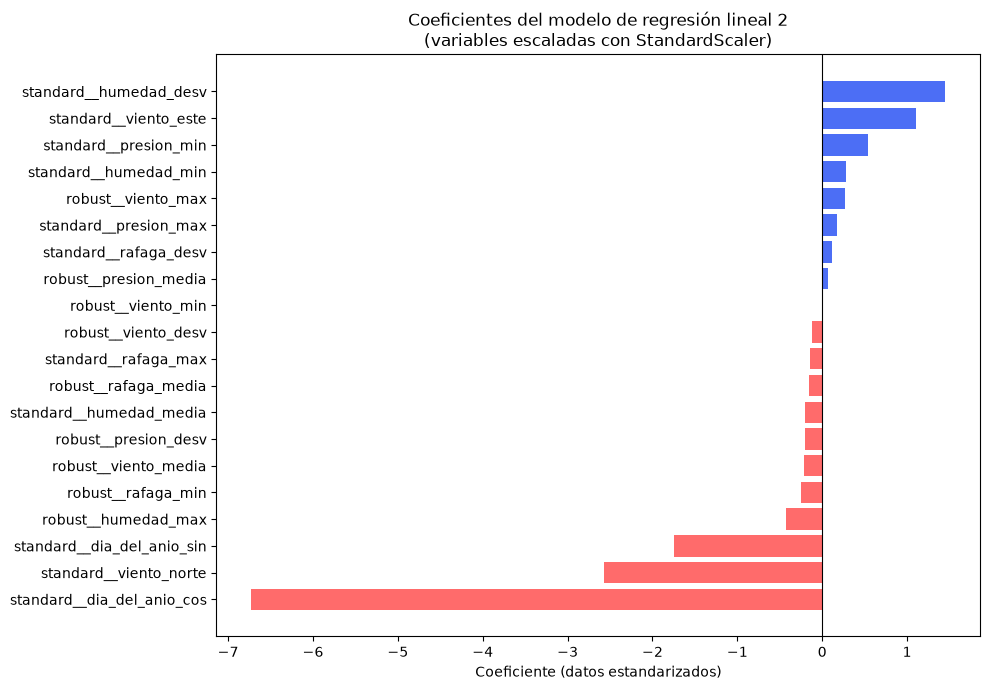

 Azul = efecto positivo en el precio  |   Rojo = efecto negativo
   Recuerda: los coeficientes son comparables entre sí porque las variables están estandarizadas.


In [126]:

coef_sorted = coef_df_2.sort_values('Coeficiente')
colors = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in coef_sorted['Coeficiente']]

plt.figure(figsize=(10, 7))
plt.barh(coef_sorted['Variable'], coef_sorted['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (datos estandarizados)')
plt.title('Coeficientes del modelo de regresión lineal 2\n(variables escaladas con StandardScaler)')
plt.tight_layout()
plt.show()
print(" Azul = efecto positivo en el precio  |   Rojo = efecto negativo")
print("   Recuerda: los coeficientes son comparables entre sí porque las variables están estandarizadas.")

In [127]:
y_train_pred = Modelo_2.predict(Xt_train_2_df)


In [128]:
Xt_train_2 = pipeline_regresion_2.transform(X_train)
Xt_train_2_df = pd.DataFrame(
    Xt_train_2.toarray() if hasattr(Xt_train_2, "toarray") else Xt_train_2,
    columns=pipeline_regresion_2.named_steps["preprocesamiento"].get_feature_names_out(),
    index=X_train.index,
)
y_train_pred_2 = Modelo_2.predict(Xt_train_2_df)

r2_train_2 = r2_score(y_train, y_train_pred_2)
rmse_train_2 = np.sqrt(mean_squared_error(y_train, y_train_pred_2))
mae_train_2 = mean_absolute_error(y_train, y_train_pred_2)
metricas_train_2 = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_train_2, rmse_train_2, mae_train_2],
    }
)
metricas_train_2

,Métrica,Valor
0,R²,0.777250
1,RMSE,4.273787
2,MAE,3.338653


In [129]:
Xt_test_2 = pipeline_regresion_2.transform(X_test)
Xt_test_2_df = pd.DataFrame(
    Xt_test_2.toarray() if hasattr(Xt_test_2, "toarray") else Xt_test_2,
    columns=pipeline_regresion_2.named_steps["preprocesamiento"].get_feature_names_out(),
    index=X_test.index,
)
y_test_pred_2 = Modelo_2.predict(Xt_test_2_df)

r2_test_2 = r2_score(y_test, y_test_pred_2)
rmse_test_2 = np.sqrt(mean_squared_error(y_test, y_test_pred_2))
mae_test_2 = mean_absolute_error(y_test, y_test_pred_2)
metricas_test_2 = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_test_2, rmse_test_2, mae_test_2],
    }
)
metricas_test_2

,Métrica,Valor
0,R²,0.631461
1,RMSE,5.770127
2,MAE,3.699641


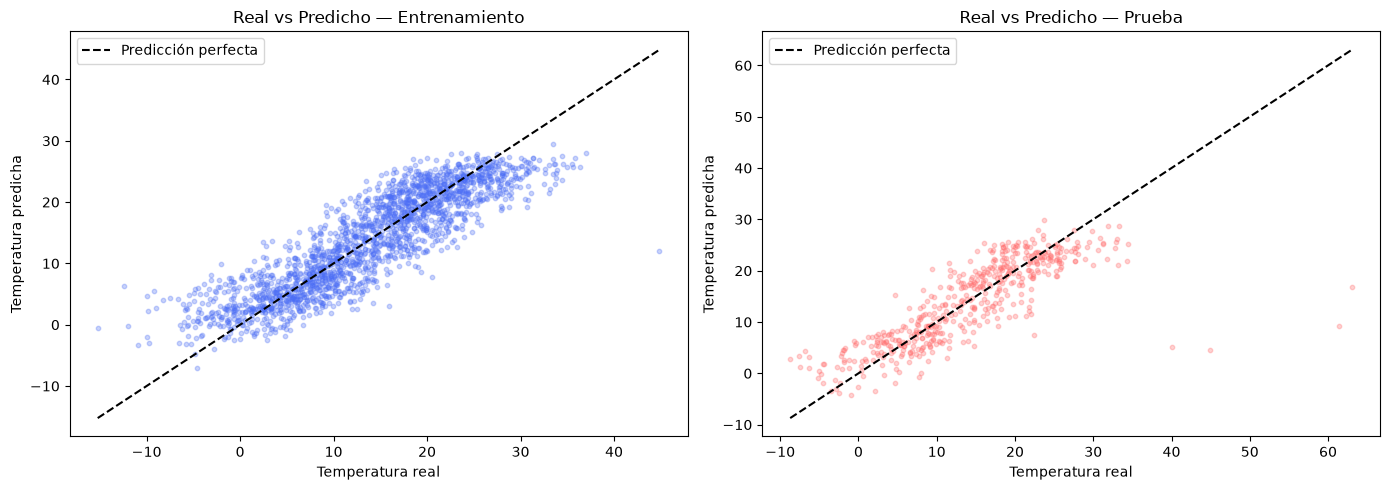

Los puntos deberían estar cerca de la línea punteada (predicción perfecta).
   La dispersión alrededor de esa línea refleja el error del modelo.


In [130]:
# Visualización: valores reales vs predichos (train y test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_real, y_pred, titulo, color in [
    (axes[0], y_train, y_train_pred_2, 'Entrenamiento', '#4C6EF5'),
    (axes[1], y_test,  y_test_pred_2,  'Prueba',        '#FF6B6B')
]:
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.3, color=color, s=10)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Temperatura real')
    ax.set_ylabel('Temperatura predicha')
    ax.set_title(f'Real vs Predicho — {titulo}')
    ax.legend()

plt.tight_layout()
plt.show()
print("Los puntos deberían estar cerca de la línea punteada (predicción perfecta).")
print("   La dispersión alrededor de esa línea refleja el error del modelo.")

### 2.3 Tercer modelo de regresión

Para este tercer modelo, reutilizaremos exactamente el mismo preprocesamiento del segundo modelo (`pipeline_regresion_2`), pero en lugar de una regresión lineal simple entrenaremos una regresión Lasso (regularización L1).

La regularización Lasso agrega una penalización proporcional a la suma de los valores absolutos de los coeficientes. Esto reduce el riesgo de sobreajuste al penalizar coeficientes muy grandes, especialmente relevante aquí porque tenemos varias variables correlacionadas entre sí (por ejemplo, *viento_media*, *viento_max*, *viento_min* o las variables derivadas de ráfaga). Además, puede llevar coeficientes irrelevantes exactamente a cero, funcionando como una selección automática de variables y facilitando la interpretación del modelo.

Para elegir la fuerza de la regularización (el hiperparámetro $\alpha$) usaremos `LassoCV`, que prueba varios valores de $\alpha$ mediante validación cruzada sobre el conjunto de entrenamiento y selecciona el que minimiza el error.

In [131]:
from sklearn.linear_model import Lasso, LassoCV

Modelo_3_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
Modelo_3_cv.fit(Xt_train_2_df, y_train)

alpha_optimo = Modelo_3_cv.alpha_
print("Alpha óptimo seleccionado por validación cruzada:", alpha_optimo)

Modelo_3 = Lasso(alpha=alpha_optimo, random_state=42, max_iter=10000)
Modelo_3.fit(Xt_train_2_df, y_train)

Alpha óptimo seleccionado por validación cruzada: 0.0448771356128122


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0.0448771356128122)
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [132]:
coef_df_3 = pd.DataFrame({
    "Variable": Xt_train_2_df.columns,
    "Coeficiente": Modelo_3.coef_,
})

variables_eliminadas = (coef_df_3["Coeficiente"] == 0).sum()
print("Variables llevadas a cero por Lasso:", variables_eliminadas, "de", len(coef_df_3))

coef_df_3

Variables llevadas a cero por Lasso: 4 de 20


,Variable,Coeficiente
0,robust__presion_media,0.009811
1,robust__presion_desv,-0.067440
2,robust__viento_media,0.000000
3,robust__viento_min,-0.043562
4,robust__viento_max,0.061580
5,robust__viento_desv,0.000000
6,robust__rafaga_media,-0.196620
7,robust__rafaga_min,-0.224536
8,robust__humedad_max,-0.344572
9,standard__presion_min,0.750467


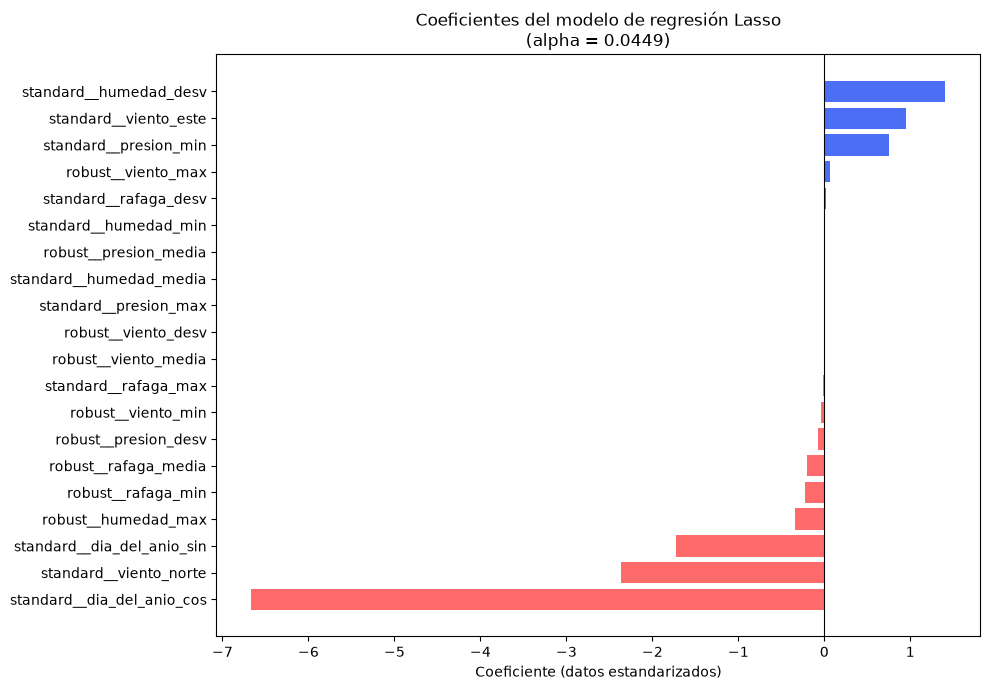

 Azul = efecto positivo en el precio  |   Rojo = efecto negativo
   Las variables con coeficiente en 0 fueron descartadas por la regularización Lasso.


In [133]:
coef_sorted = coef_df_3.sort_values('Coeficiente')
colors = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in coef_sorted['Coeficiente']]

plt.figure(figsize=(10, 7))
plt.barh(coef_sorted['Variable'], coef_sorted['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (datos estandarizados)')
plt.title(f'Coeficientes del modelo de regresión Lasso\n(alpha = {alpha_optimo:.4f})')
plt.tight_layout()
plt.show()
print(" Azul = efecto positivo en el precio  |   Rojo = efecto negativo")
print("   Las variables con coeficiente en 0 fueron descartadas por la regularización Lasso.")

#### 2.3.1 Métricas del modelo Lasso en los datos de entrenamiento

In [134]:
y_train_pred_3 = Modelo_3.predict(Xt_train_2_df)

r2_train_3 = r2_score(y_train, y_train_pred_3)
rmse_train_3 = np.sqrt(mean_squared_error(y_train, y_train_pred_3))
mae_train_3 = mean_absolute_error(y_train, y_train_pred_3)
metricas_train_3 = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_train_3, rmse_train_3, mae_train_3],
    }
)
metricas_train_3

,Métrica,Valor
0,R²,0.776603
1,RMSE,4.279993
2,MAE,3.344529


#### 2.3.2 Métricas del modelo Lasso en los datos de validación

In [135]:
Xt_test_3 = pipeline_regresion_2.transform(X_test)
Xt_test_3_df = pd.DataFrame(
    Xt_test_3.toarray() if hasattr(Xt_test_3, "toarray") else Xt_test_3,
    columns=pipeline_regresion_2.named_steps["preprocesamiento"].get_feature_names_out(),
    index=X_test.index,
)
y_test_pred_3 = Modelo_3.predict(Xt_test_3_df)

r2_test_3 = r2_score(y_test, y_test_pred_3)
rmse_test_3 = np.sqrt(mean_squared_error(y_test, y_test_pred_3))
mae_test_3 = mean_absolute_error(y_test, y_test_pred_3)
metricas_test_3 = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_test_3, rmse_test_3, mae_test_3],
    }
)
metricas_test_3

,Métrica,Valor
0,R²,0.632525
1,RMSE,5.761786
2,MAE,3.694084


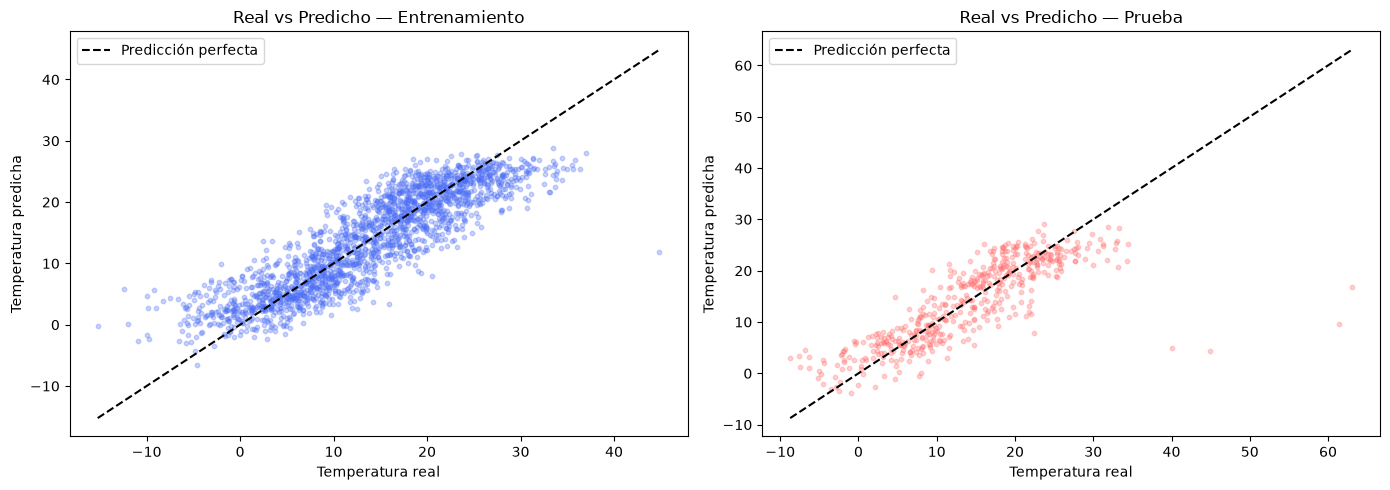

Los puntos deberían estar cerca de la línea punteada (predicción perfecta).
   La dispersión alrededor de esa línea refleja el error del modelo.


In [136]:
# Visualización: valores reales vs predichos (train y test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_real, y_pred, titulo, color in [
    (axes[0], y_train, y_train_pred_3, 'Entrenamiento', '#4C6EF5'),
    (axes[1], y_test,  y_test_pred_3,  'Prueba',        '#FF6B6B')
]:
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.3, color=color, s=10)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Temperatura real')
    ax.set_ylabel('Temperatura predicha')
    ax.set_title(f'Real vs Predicho — {titulo}')
    ax.legend()

plt.tight_layout()
plt.show()
print("Los puntos deberían estar cerca de la línea punteada (predicción perfecta).")
print("   La dispersión alrededor de esa línea refleja el error del modelo.")

### 2.4 Cuarto modelo de regresión

#### 2.4.1 Cálculo del VIF

En el segundo modelo eliminamos *direccion_viento*, *mes*, *estacion_anio* y *sector_viento* asumiendo que eran redundantes frente a otras variables, pero esa decisión se tomó sin evidencia cuantitativa. Por ello, calcularemos el factor de inflación de la varianza (VIF) sobre todas las variables originales explicativas (excluyendo únicamente *fecha*, *anio* y *registros_del_dia*, que no son predictivas o no generalizan), incluyendo de nuevo esas cuatro variables descartadas.

El VIF de una variable mide qué tan bien puede explicarse esa variable a partir de una combinación lineal de las demás variables predictoras. En este caso, valores altos indican que la variable es redundante (multicolinealidad), lo cual infla la varianza de los coeficientes estimados y hace inestable e inconsistente su interpretación.

Usaremos como regla general que un VIF mayor a 10 indica una colinealidad problemática. Eliminaremos iterativamente la variable con el VIF más alto por encima de ese umbral, recalculando el VIF de las restantes, hasta quedarnos únicamente con variables razonablemente independientes entre sí.

Como el VIF requiere variables numéricas, las variables categóricas (*mes*, *estacion_anio*, *sector_viento*) se codificarán con one-hot encoding (usando `drop_first` para evitar la colinealidad trivial de las variables dummy) y las variables numéricas se imputarán con la mediana.

In [137]:
%pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [138]:
from sklearn.base import BaseEstimator
from sklearn.feature_selection import SelectorMixin
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def calcular_vif(df):
    df_const = add_constant(df)
    vif = pd.DataFrame()
    vif["Variable"] = df_const.columns
    vif["VIF"] = [
        variance_inflation_factor(df_const.values, i)
        for i in range(df_const.shape[1])
    ]
    return vif[vif["Variable"] != "const"].sort_values("VIF", ascending=False)


class SelectorVIF(BaseEstimator, SelectorMixin):
    """Selector de variables (compatible con sklearn.feature_selection) que elimina
    iterativamente la variable con mayor VIF (calculado con statsmodels) hasta que
    todas las restantes queden por debajo del umbral indicado."""

    def __init__(self, umbral=10):
        self.umbral = umbral

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        self.feature_names_in_ = np.array(X_df.columns, dtype=object)
        self.n_features_in_ = X_df.shape[1]

        variables_restantes = list(X_df.columns)
        self.historial_eliminadas_ = []

        while len(variables_restantes) > 1:
            vif_actual = calcular_vif(X_df[variables_restantes])
            vif_maximo = vif_actual["VIF"].max()

            if vif_maximo <= self.umbral:
                break

            variable_a_eliminar = vif_actual.loc[vif_actual["VIF"].idxmax(), "Variable"]
            self.historial_eliminadas_.append((variable_a_eliminar, vif_maximo))
            variables_restantes.remove(variable_a_eliminar)

        self.variables_seleccionadas_ = variables_restantes
        return self

    def _get_support_mask(self):
        return np.isin(self.feature_names_in_, self.variables_seleccionadas_)


# Variables numéricas originales (incluyendo direccion_viento, excluida en el modelo 2)
imputer_numerico_vif = SimpleImputer(strategy="median")
X_train_numerico_vif = pd.DataFrame(
    imputer_numerico_vif.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

# Variables categóricas originales (mes, estacion_anio, sector_viento) codificadas con one-hot
X_train_categorico_vif = pd.get_dummies(
    X_train[categorical_features].astype("object"),
    drop_first=True,
)

Xt_train_vif_df = pd.concat([X_train_numerico_vif, X_train_categorico_vif], axis=1)

UMBRAL_VIF = 10
selector_vif = SelectorVIF(umbral=UMBRAL_VIF)
selector_vif.fit(Xt_train_vif_df)

variables_actuales = selector_vif.variables_seleccionadas_
variables_eliminadas_vif = selector_vif.historial_eliminadas_

print("Variables eliminadas por alta colinealidad (VIF > 10):")
for variable, vif_valor in variables_eliminadas_vif:
    print(f"  - {variable}: VIF = {vif_valor:.2f}")

print(f"\nVariables independientes restantes ({len(variables_actuales)} de {len(Xt_train_vif_df.columns)}):")
print(variables_actuales)

vif_final = calcular_vif(Xt_train_vif_df[variables_actuales])
vif_final

/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_39369/4182606895.py:12: UserWarning: The design matrix is poorly conditioned (condition number=9.77e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(df_const.values, i)
/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: S

Variables eliminadas por alta colinealidad (VIF > 10):
  - estacion_anio_otono: VIF = 1000799917193443.50
  - estacion_anio_primavera: VIF = 1000799917193443.50
  - mes_June: VIF = 1000799917193443.50
  - dia_del_anio: VIF = 146.06
  - presion_min: VIF = 14.74
  - sector_viento_SW: VIF = 11.49

Variables independientes restantes (35 de 41):
['presion_media', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'estacion_anio_verano', 'mes_August', 'mes_December', 'mes_February', 'mes_January', 'mes_July', 'mes_March', 'mes_May', 'mes_November', 'mes_October', 'mes_September', 'sector_viento_N', 'sector_viento_NE', 'sector_viento_NW', 'sector_viento_S', 'sector_viento_SE', 'sector_viento_W']


,Variable,VIF
12,rafaga_media,5.385233
16,viento_norte,5.294075
8,viento_media,5.163546
17,viento_este,4.884792
19,estacion_anio_verano,4.755423
31,sector_viento_NE,4.458022
10,viento_max,4.265324
18,direccion_viento,4.149865
5,humedad_min,3.697536
4,humedad_media,3.223687


#### 2.4.2 Cuarto modelo: Lasso solo con variables independientes

Con la lista de variables cuyo VIF quedó por debajo de 10 (que ahora puede incluir variables numéricas originales y categorías dummy que el segundo modelo había descartado), estandarizaremos las variables numéricas resultantes y entrenaremos un nuevo modelo Lasso. Al igual que en el tercer modelo, usaremos `LassoCV` para elegir el hiperparámetro $\alpha$ óptimo.

In [139]:
scaler_4 = StandardScaler()
Xt_train_4_df = pd.DataFrame(
    scaler_4.fit_transform(Xt_train_vif_df[variables_actuales]),
    columns=variables_actuales,
    index=X_train.index,
)

Modelo_4_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
Modelo_4_cv.fit(Xt_train_4_df, y_train)

alpha_optimo_4 = Modelo_4_cv.alpha_
print("Alpha óptimo seleccionado por validación cruzada:", alpha_optimo_4)

Modelo_4 = Lasso(alpha=alpha_optimo_4, random_state=42, max_iter=10000)
Modelo_4.fit(Xt_train_4_df, y_train)

Alpha óptimo seleccionado por validación cruzada: 0.020871480272833354


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0....1480272833354)
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [140]:
coef_df_4 = pd.DataFrame({
    "Variable": Xt_train_4_df.columns,
    "Coeficiente": Modelo_4.coef_,
})

variables_eliminadas_4 = (coef_df_4["Coeficiente"] == 0).sum()
print("Variables llevadas a cero por Lasso:", variables_eliminadas_4, "de", len(coef_df_4))

coef_df_4

Variables llevadas a cero por Lasso: 1 de 35


,Variable,Coeficiente
0,presion_media,0.056867
1,presion_max,0.539943
2,presion_desv,-0.381528
3,humedad_media,-0.077827
4,humedad_min,0.086742
5,humedad_max,-0.433439
6,humedad_desv,1.493563
7,viento_media,0.000000
8,viento_min,-0.263031
9,viento_max,0.186856


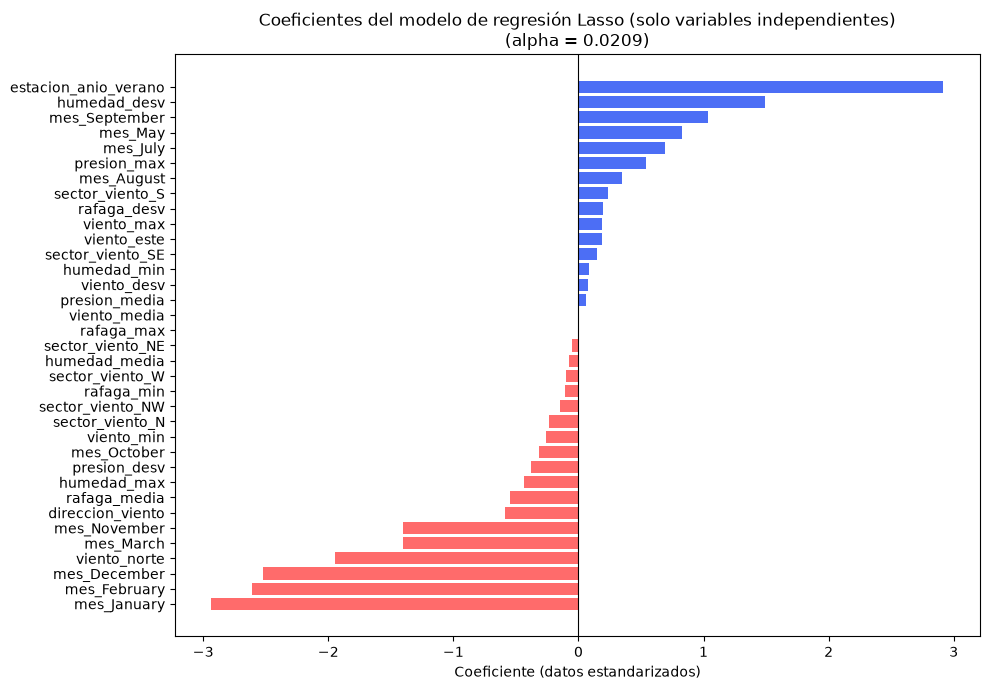

 Azul = efecto positivo en el precio  |   Rojo = efecto negativo
   Las variables con coeficiente en 0 fueron descartadas por la regularización Lasso.


In [141]:
coef_sorted = coef_df_4.sort_values('Coeficiente')
colors = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in coef_sorted['Coeficiente']]

plt.figure(figsize=(10, 7))
plt.barh(coef_sorted['Variable'], coef_sorted['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (datos estandarizados)')
plt.title(f'Coeficientes del modelo de regresión Lasso (solo variables independientes)\n(alpha = {alpha_optimo_4:.4f})')
plt.tight_layout()
plt.show()
print(" Azul = efecto positivo en el precio  |   Rojo = efecto negativo")
print("   Las variables con coeficiente en 0 fueron descartadas por la regularización Lasso.")

#### 2.4.3 Métricas del cuarto modelo en los datos de entrenamiento

In [142]:
y_train_pred_4 = Modelo_4.predict(Xt_train_4_df)

r2_train_4 = r2_score(y_train, y_train_pred_4)
rmse_train_4 = np.sqrt(mean_squared_error(y_train, y_train_pred_4))
mae_train_4 = mean_absolute_error(y_train, y_train_pred_4)
metricas_train_4 = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_train_4, rmse_train_4, mae_train_4],
    }
)
metricas_train_4

,Métrica,Valor
0,R²,0.770937
1,RMSE,4.333935
2,MAE,3.387780


#### 2.4.4 Métricas del cuarto modelo en los datos de validación

In [143]:
# Se aplica la misma imputación, codificación y escalamiento ajustados en el conjunto de entrenamiento.
X_test_numerico_vif = pd.DataFrame(
    imputer_numerico_vif.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)
X_test_categorico_vif = pd.get_dummies(
    X_test[categorical_features].astype("object"),
    drop_first=True,
).reindex(columns=X_train_categorico_vif.columns, fill_value=0)

Xt_test_vif_df = pd.concat([X_test_numerico_vif, X_test_categorico_vif], axis=1)
Xt_test_4_df = pd.DataFrame(
    scaler_4.transform(Xt_test_vif_df[variables_actuales]),
    columns=variables_actuales,
    index=X_test.index,
)
y_test_pred_4 = Modelo_4.predict(Xt_test_4_df)

r2_test_4 = r2_score(y_test, y_test_pred_4)
rmse_test_4 = np.sqrt(mean_squared_error(y_test, y_test_pred_4))
mae_test_4 = mean_absolute_error(y_test, y_test_pred_4)
metricas_test_4 = pd.DataFrame(
    {
        "Métrica": ["R²", "RMSE", "MAE"],
        "Valor": [r2_test_4, rmse_test_4, mae_test_4],
    }
)
metricas_test_4

,Métrica,Valor
0,R²,0.607485
1,RMSE,5.954858
2,MAE,3.927683


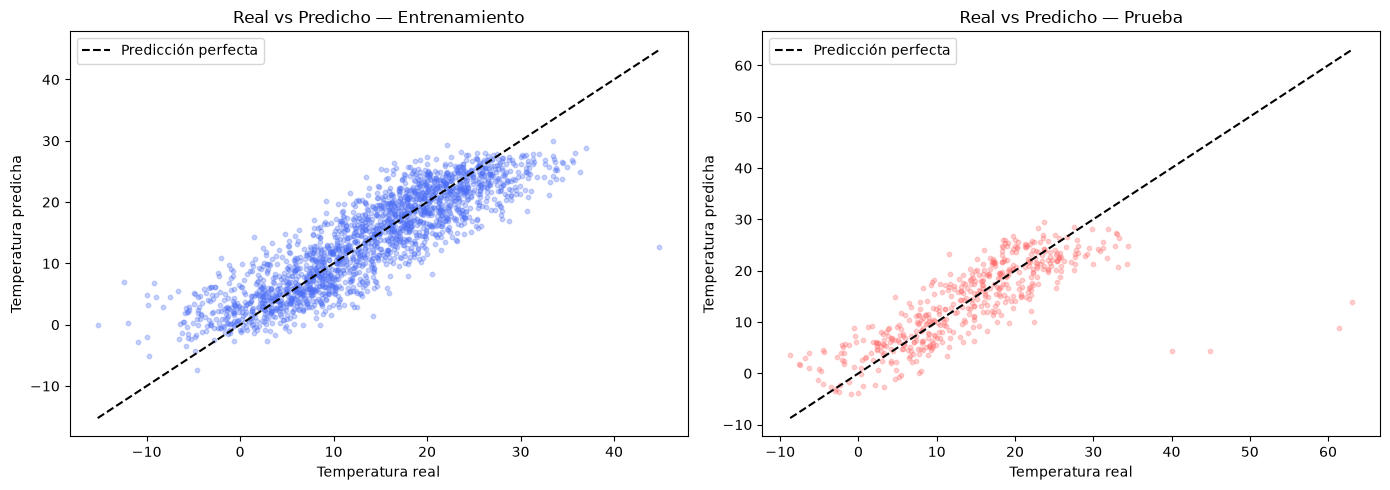

Los puntos deberían estar cerca de la línea punteada (predicción perfecta).
   La dispersión alrededor de esa línea refleja el error del modelo.


In [144]:
# Visualización: valores reales vs predichos (train y test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_real, y_pred, titulo, color in [
    (axes[0], y_train, y_train_pred_4, 'Entrenamiento', '#4C6EF5'),
    (axes[1], y_test,  y_test_pred_4,  'Prueba',        '#FF6B6B')
]:
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.3, color=color, s=10)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Temperatura real')
    ax.set_ylabel('Temperatura predicha')
    ax.set_title(f'Real vs Predicho — {titulo}')
    ax.legend()

plt.tight_layout()
plt.show()
print("Los puntos deberían estar cerca de la línea punteada (predicción perfecta).")
print("   La dispersión alrededor de esa línea refleja el error del modelo.")

### 2.6 Tabla comparativa de los errores de los cuatro modelos

A continuación, haremos una tabla comparativa de los errores de los cuatro modelos. Podemos ver en este caso que el modelo 3 hizo la mejor predicción.

In [145]:
metricas_comparativas = pd.DataFrame({
    "Métrica": ["R²", "RMSE", "MAE"],
    "Modelo 1 (Regresión Lineal)": [r2_test, rmse_test, mae_test],
    "Modelo 2 (Regresión Lineal con preprocesamiento avanzado)": [r2_test_2, rmse_test_2, mae_test_2],
    "Modelo 3 (Lasso con preprocesamiento avanzado)": [r2_test_3, rmse_test_3, mae_test_3],
    "Modelo 4 (Lasso con selección de variables por VIF)": [r2_test_4, rmse_test_4, mae_test_4],
})
metricas_comparativas

,Métrica,Modelo 1 (Regresión Lineal),Modelo 2 (Regresión Lineal con preprocesamiento avanzado),Modelo 3 (Lasso con preprocesamiento avanzado),Modelo 4 (Lasso con selección de variables por VIF)
0,R²,0.607559,0.631461,0.632525,0.607485
1,RMSE,5.954296,5.770127,5.761786,5.954858
2,MAE,3.919093,3.699641,3.694084,3.927683


## 3. Verificación de supuestos y comparación de los cuatro modelos

Hasta ahora hemos comparado los cuatro modelos únicamente por sus métricas de error (R², RMSE, MAE). Sin embargo, la regresión lineal (y su versión regularizada, Lasso) solo permite interpretar sus coeficientes como efectos confiables si se cumplen ciertos supuestos estadísticos sobre los errores del modelo.

En esta sección verificaremos, para los cuatro modelos entrenados, los siguientes supuestos:

| Supuesto | ¿Qué verifica? | Prueba de diagnóstico |
|----------|--------------|----------------------|
| **No colinealidad** | Variables predictoras no correlacionadas entre sí | VIF |
| **Normalidad de errores** | Los residuales siguen una distribución normal | Shapiro-Wilk, histograma, Q-Q plot |
| **Homocedasticidad** | Varianza constante de los residuales | Breusch-Pagan |
| **Independencia de errores** | Los errores no están autocorrelacionados | Durbin-Watson |
| **Linealidad** | Relación lineal entre las variables y la variable objetivo | Test de Rainbow |

Para cada modelo usaremos su propio conjunto de variables preprocesadas (`Xt_train_df` para el modelo 1, `Xt_train_2_df` para los modelos 2 y 3, y `Xt_train_4_df` para el modelo 4) y sus respectivos residuales de entrenamiento.

En este caso, haremos un análisis de supuestos similar al presente en la práctica ``P42_Verificación de supuestos de regresión lineal``. 

### 3.1 Multicolinealidad (VIF)

A continuación calculamos el VIF una sola vez (sin eliminación iterativa) sobre todas las variables numéricas originales y categóricas codificadas (`Xt_train_vif_df`, construido en la sección 2.4.1), y lo visualizamos con un gráfico de barras y líneas de referencia en VIF=5 (colinealidad moderada) y VIF=10 (colinealidad alta).

In [146]:
vif_completo = calcular_vif(Xt_train_vif_df)
vif_completo

/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_39369/4182606895.py:12: UserWarning: The design matrix is poorly conditioned (condition number=9.77e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(df_const.values, i)
/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: S

,Variable,VIF
21,estacion_anio_otono,1.000800e+15
34,mes_September,1.000800e+15
33,mes_October,1.000800e+15
32,mes_November,1.000800e+15
29,mes_June,1.000800e+15
28,mes_July,1.000800e+15
27,mes_January,1.000800e+15
26,mes_February,1.000800e+15
25,mes_December,1.000800e+15
24,mes_August,1.000800e+15


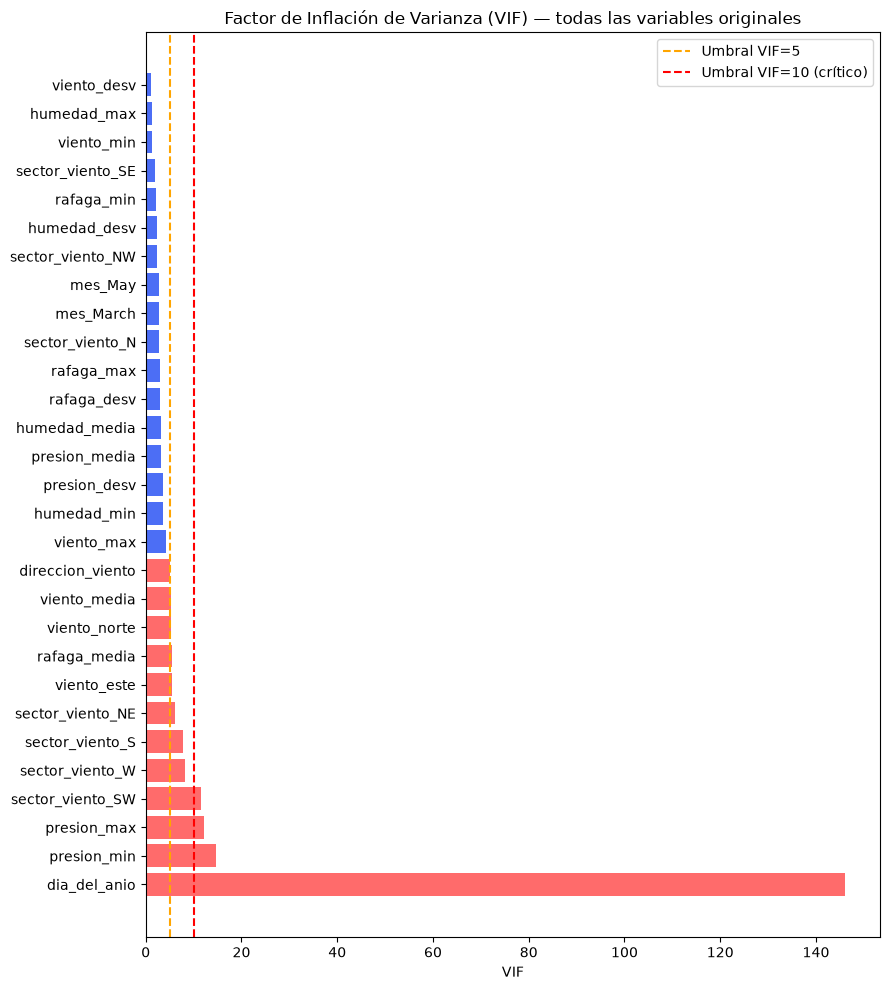

Variables con VIF infinito (multicolinealidad perfecta): ['estacion_anio_otono', 'mes_September', 'mes_October', 'mes_November', 'mes_June', 'mes_July', 'mes_January', 'mes_February', 'mes_December', 'mes_August', 'estacion_anio_verano', 'estacion_anio_primavera']


In [147]:
# Visualización del VIF (estilo del notebook de referencia)
# Los VIF numéricamente enormes (>1e6) se tratan como colinealidad perfecta/infinita.
UMBRAL_VIF_INFINITO = 1e6
es_finito = np.isfinite(vif_completo['VIF']) & (vif_completo['VIF'] < UMBRAL_VIF_INFINITO)
vif_finito = vif_completo[es_finito].sort_values('VIF', ascending=False)
vif_inf = vif_completo[~es_finito]

fig, ax = plt.subplots(figsize=(9, 10))
colors_vif = ['#FF6B6B' if v >= 5 else '#4C6EF5' for v in vif_finito['VIF']]
ax.barh(vif_finito['Variable'], vif_finito['VIF'], color=colors_vif)
ax.axvline(5, color='orange', linestyle='--', lw=1.5, label='Umbral VIF=5')
ax.axvline(10, color='red', linestyle='--', lw=1.5, label='Umbral VIF=10 (crítico)')
ax.set_xlabel('VIF')
ax.set_title('Factor de Inflación de Varianza (VIF) — todas las variables originales')
ax.legend()
plt.tight_layout()
plt.show()

if len(vif_inf) > 0:
    print(f"Variables con VIF infinito (multicolinealidad perfecta): {list(vif_inf['Variable'])}")

### 3.2 Preparación: predicciones y residuales de los cuatro modelos

Calculamos, de forma explícita e independiente, las predicciones y residuales de entrenamiento de cada modelo, para evitar cualquier ambigüedad con variables reutilizadas en secciones anteriores.

In [148]:
pred_m1 = Modelo_1.predict(Xt_train_df)
pred_m2 = Modelo_2.predict(Xt_train_2_df)
pred_m3 = Modelo_3.predict(Xt_train_2_df)
pred_m4 = Modelo_4.predict(Xt_train_4_df)

resid_m1 = np.array(y_train - pred_m1)
resid_m2 = np.array(y_train - pred_m2)
resid_m3 = np.array(y_train - pred_m3)
resid_m4 = np.array(y_train - pred_m4)

modelos_info = {
    "Modelo 1 (Regresión lineal)": {"X": Xt_train_df, "pred": pred_m1, "resid": resid_m1},
    "Modelo 2 (Regresión lineal, preproc. avanzado)": {"X": Xt_train_2_df, "pred": pred_m2, "resid": resid_m2},
    "Modelo 3 (Lasso)": {"X": Xt_train_2_df, "pred": pred_m3, "resid": resid_m3},
    "Modelo 4 (Lasso, variables independientes por VIF)": {"X": Xt_train_4_df, "pred": pred_m4, "resid": resid_m4},
}

print("Modelos preparados para el análisis de supuestos:", list(modelos_info.keys()))

Modelos preparados para el análisis de supuestos: ['Modelo 1 (Regresión lineal)', 'Modelo 2 (Regresión lineal, preproc. avanzado)', 'Modelo 3 (Lasso)', 'Modelo 4 (Lasso, variables independientes por VIF)']


### 3.3 Normalidad de los errores

Al igual que en el notebook de referencia, usamos la prueba de **Shapiro-Wilk** (p-value > 0.05 → no se rechaza normalidad), junto con el histograma y el Q-Q plot de los residuales de cada modelo. El test de Shapiro-Wilk es una prueba de hipótesis que busca probar si los datos (en este caso los residuos) están distribuidos normalmente. El estadístico que usamos está dado por: $$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}
{\sum_{i=1}^{n}(x_i-\bar{x})^2}$$ con $x_{(i)}$ el i-ésimo estadístico de orden. En este caso, el estadístico puede calcularse usando la función ``shapiro`` de la librería ``statsmodels``. En este caso, usando el estadístico calculado, usamos un p-valor que nos indica la probabilidad de que los errores tengan la distribución obtenida suponiendo que están normalmente distribuidos).

In [149]:
from scipy.stats import shapiro
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

shapiro_resultados = []
for nombre, info in modelos_info.items():
    estat, p_shapiro = shapiro(info["resid"])
    shapiro_resultados.append({"Modelo": nombre, "Estadístico": estat, "p-value": p_shapiro})
    info["shapiro_p"] = p_shapiro

shapiro_df = pd.DataFrame(shapiro_resultados)
shapiro_df

,Modelo,Estadístico,p-value
0,Modelo 1 (Regresión lineal),0.990190,2.869129e-10
1,"Modelo 2 (Regresión lineal, preproc. avanzado)",0.990293,3.400453e-10
2,Modelo 3 (Lasso),0.990312,3.509156e-10
3,"Modelo 4 (Lasso, variables independientes por VIF)",0.990561,5.320499e-10


En este caso, los resultados de la prueba de Shapiro-Wilk muestran que los residuales de todos los modelos tienen p-values menores a 0.05, lo que indica que se rechaza la hipótesis nula de normalidad. Esto sugiere que los errores no siguen una distribución normal, lo cual puede afectar la validez de las inferencias y la interpretación de los coeficientes del modelo.

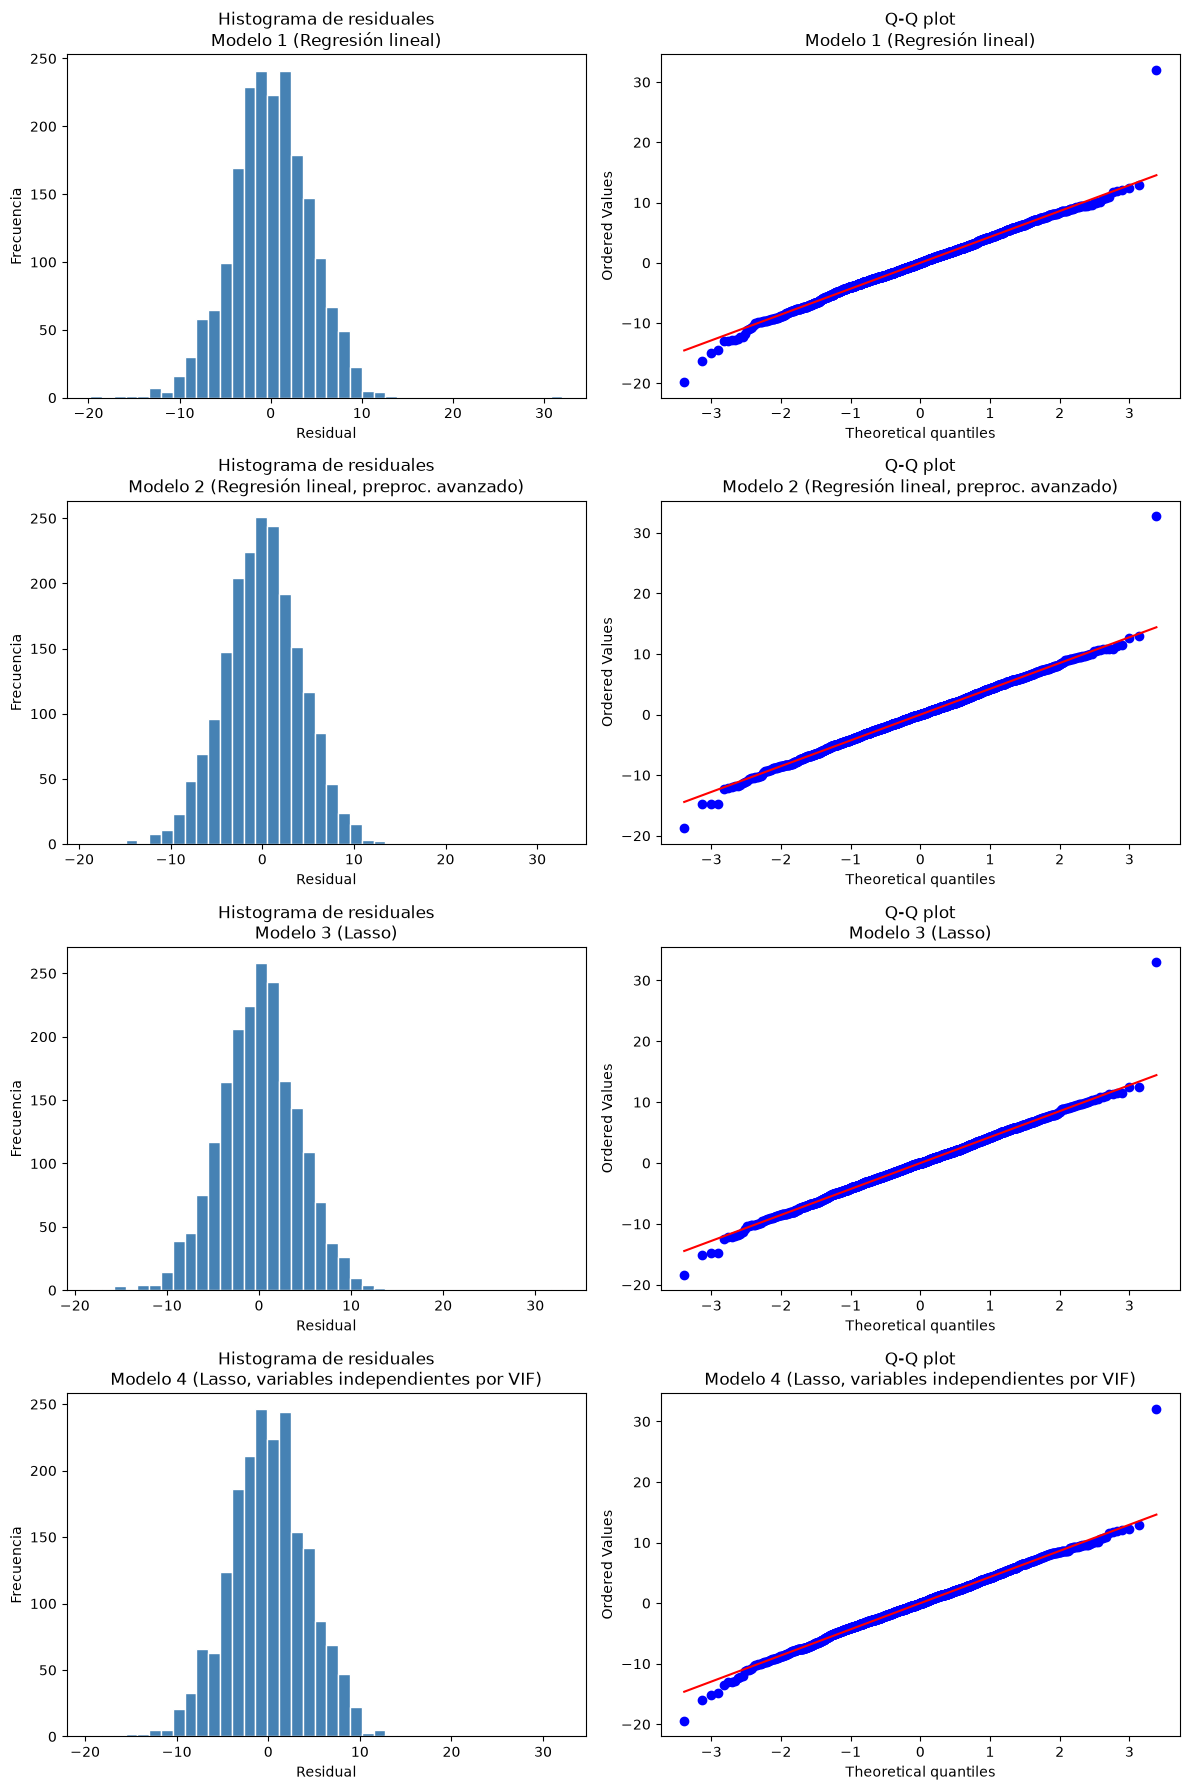

In [150]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

for fila, (nombre, info) in enumerate(modelos_info.items()):
    resid = info["resid"]

    axes[fila, 0].hist(resid, bins=40, color="steelblue", edgecolor="white")
    axes[fila, 0].set_title(f"Histograma de residuales\n{nombre}")
    axes[fila, 0].set_xlabel("Residual")
    axes[fila, 0].set_ylabel("Frecuencia")

    stats.probplot(resid, dist="norm", plot=axes[fila, 1])
    axes[fila, 1].set_title(f"Q-Q plot\n{nombre}")

plt.tight_layout()
plt.show()

También graficamos Q-Q plots para evaluar la normalidad de los residuales. En un Q-Q plot, si los puntos se alinean aproximadamente a lo largo de la línea diagonal, esto sugiere que los residuales siguen una distribución normal. Desviaciones significativas de esta línea indican posibles problemas de normalidad. Vemos que los residuales de todos los modelos muestran desviaciones de la línea diagonal, especialmente en las colas, lo que refuerza la conclusión de que los errores no son normalmente distribuidos.

### 3.4 Homocedasticidad (Breusch-Pagan)

Verificamos si la varianza de los residuales es constante para los cuatro modelos con la prueba de Breusch-Pagan (p-value < 0.05 indica heterocedasticidad). Esta prueba nos indica directamente si la varianza de los errores es constante o no. Esta prueba de hipótesis también está implementada en la librería ``statsmodels`` y nos devuelve un p-value que nos indica la probabilidad de que los errores tengan varianza constante suponiendo que son homocedásticos.



In [151]:
bp_resultados = []
for nombre, info in modelos_info.items():
    X_const = sm.add_constant(info["X"].reset_index(drop=True))
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(info["resid"], X_const)
    bp_resultados.append({"Modelo": nombre, "Estadístico": bp_stat, "p-value": bp_pvalue})
    info["bp_p"] = bp_pvalue

bp_df = pd.DataFrame(bp_resultados)
bp_df

/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()


,Modelo,Estadístico,p-value
0,Modelo 1 (Regresión lineal),67.861279,0.011954
1,"Modelo 2 (Regresión lineal, preproc. avanzado)",55.373404,0.000036
2,Modelo 3 (Lasso),54.126799,0.000055
3,"Modelo 4 (Lasso, variables independientes por VIF)",67.839971,0.000722


En este caso, los p-values obtenidos para todos los modelos son menores a 0.05, lo que indica que se rechaza la hipótesis nula de homocedasticidad. Esto sugiere que la varianza de los errores no es constante y que hay heterocedasticidad presente en los modelos.

### 3.5 Independencia de los errores (Durbin-Watson)

El estadístico de Durbin-Watson varía entre 0 y 4; valores cercanos a 2 indican ausencia de autocorrelación entre los residuales. Esta prueba nos permite evaluar si los errores del modelo están correlacionados entre sí, lo cual es importante para la validez de las inferencias y la eficiencia de los estimadores. El estadístico de Durbin-Watson se calcula como:
$$
DW = \frac{\sum_{t=2}^{n} (e_t - e_{t-1})^2}{\sum_{t=1}^{n} e_t^2}
$$  
donde $e_t$ son los residuales del modelo en el tiempo t. Un valor cercano a 2 indica que no hay autocorrelación, mientras que valores cercanos a 0 o 4 indican autocorrelación positiva o negativa, respectivamente.

In [152]:
dw_resultados = []
for nombre, info in modelos_info.items():
    dw = durbin_watson(info["resid"])
    dw_resultados.append({"Modelo": nombre, "Durbin-Watson": dw})
    info["dw"] = dw

dw_df = pd.DataFrame(dw_resultados)
dw_df

,Modelo,Durbin-Watson
0,Modelo 1 (Regresión lineal),2.025366
1,"Modelo 2 (Regresión lineal, preproc. avanzado)",2.017636
2,Modelo 3 (Lasso),2.021596
3,"Modelo 4 (Lasso, variables independientes por VIF)",2.027566


En este caso vemos que todos los modelos tienen un estadístico de Durbin-Watson cercano a 2, lo que indica que no hay evidencia de autocorrelación significativa en los residuales. Esto sugiere que los errores son independientes entre sí, cumpliendo este supuesto de la regresión lineal.

### 3.6 Linealidad (Test de Rainbow)

El test de Rainbow evalúa si la relación entre las variables explicativas y la variable objetivo puede describirse razonablemente con un modelo lineal (p-value > 0.05 → no hay evidencia para rechazar la linealidad). Para poder aplicar esta prueba, ajustamos un modelo OLS de `statsmodels` sobre el mismo conjunto de variables usado por cada modelo (esto es un diagnóstico de la forma funcional del conjunto de variables, independiente de si el modelo original usaba regularización Lasso).

In [153]:
rainbow_resultados = []
for nombre, info in modelos_info.items():
    X_const = sm.add_constant(info["X"].reset_index(drop=True))
    y_reset = y_train.reset_index(drop=True)

    modelo_ols = sm.OLS(y_reset, X_const).fit()
    rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_ols)


    rainbow_resultados.append({"Modelo": nombre, "Estadístico": rainbow_stat, "p-value": rainbow_pvalue})
    info["rainbow_p"] = rainbow_pvalue

rainbow_df = pd.DataFrame(rainbow_resultados)
rainbow_df

/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_39369/3968799155.py:6: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  modelo_ols = sm.OLS(y_reset, X_const).fit()
/Users/pedropablosanintrujillo/GitHub/labs-aprendizaje-de-maquina/.venv/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:1764: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  res_mi = OLS(endog[mi_sl], exog[mi_sl]).fit()


,Modelo,Estadístico,p-value
0,Modelo 1 (Regresión lineal),0.959349,0.740256
1,"Modelo 2 (Regresión lineal, preproc. avanzado)",0.953774,0.769688
2,Modelo 3 (Lasso),0.953774,0.769688
3,"Modelo 4 (Lasso, variables independientes por VIF)",0.969225,0.686382


En este caso, el p-value 

### 3.8 Resumen comparativo de los cuatro modelos

La siguiente tabla consolida, para cada modelo, el resultado de cada prueba de diagnóstico.

In [154]:
resumen_filas = []
for nombre, info in modelos_info.items():
    resumen_filas.append({
        "Modelo": nombre,
        "Normalidad (Shapiro p)": f'{info["shapiro_p"]:.2e}',
        "¿Normal?": "Sí" if info["shapiro_p"] > 0.05 else "No",
        "Homocedasticidad (BP p)": f'{info["bp_p"]:.2e}',
        "¿Homocedástico?": "Sí" if info["bp_p"] > 0.05 else "No",
        "Independencia (DW)": f'{info["dw"]:.3f}',
        "¿Independiente?": "Sí" if 1.5 <= info["dw"] <= 2.5 else "No",
        "Linealidad (Rainbow p)": f'{info["rainbow_p"]:.3f}' if not np.isnan(info["rainbow_p"]) else "N/A",
        "¿Lineal?": ("Sí" if info["rainbow_p"] > 0.05 else "No") if not np.isnan(info["rainbow_p"]) else "N/A",
    })

resumen_supuestos_4_modelos = pd.DataFrame(resumen_filas).set_index("Modelo")
resumen_supuestos_4_modelos

,Normalidad (Shapiro p),¿Normal?,Homocedasticidad (BP p),¿Homocedástico?,Independencia (DW),¿Independiente?,Linealidad (Rainbow p),¿Lineal?
Modelo,,,,,,,,
Modelo 1 (Regresión lineal),2.87e-10,No,1.20e-02,No,2.025,Sí,0.740,Sí
"Modelo 2 (Regresión lineal, preproc. avanzado)",3.40e-10,No,3.61e-05,No,2.018,Sí,0.770,Sí
Modelo 3 (Lasso),3.51e-10,No,5.54e-05,No,2.022,Sí,0.770,Sí
"Modelo 4 (Lasso, variables independientes por VIF)",5.32e-10,No,7.22e-04,No,2.028,Sí,0.686,Sí


## 4 Evaluación cualitativa de los datos

**¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?**

**A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?**

**¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.**

**A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.**

**En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.**

### 4.1 Coeficientes del mejor modelo

Según la tabla comparativa de la sección 2.6, el Modelo 3 es el que mejor generaliza sobre el conjunto de prueba (R² = 0.6325, apenas por encima del Modelo 2 con R² = 0.6315). Sus coeficientes, obtenidos con $\alpha = 0.0449$ e intercepto $\beta_0 = 13.78$, son:

| Variable | Coeficiente | Variable | Coeficiente |
|---|---|---|---|
| presion_media | 0.0098 | humedad_min | 0.0100 |
| presion_desv | -0.0674 | humedad_desv | 1.4075 |
| viento_media | 0.0000 (eliminada) | rafaga_max | -0.0154 |
| viento_min | -0.0436 | rafaga_desv | 0.0165 |
| viento_max | 0.0616 | viento_norte | -2.3640 |
| viento_desv | 0.0000 (eliminada) | viento_este | 0.9505 |
| rafaga_media | -0.1966 | dia_del_anio_cos | -6.6657 |
| rafaga_min | -0.2245 | dia_del_anio_sin | -1.7196 |
| humedad_max | -0.3446 | presion_max | 0.0000 (eliminada) |
| presion_min | 0.7505 | humedad_media | 0.0000 (eliminada) |

Como todas las variables numéricas están estandarizadas (media 0, desviación 1), los coeficientes son comparables directamente en magnitud. Las variables con mayor peso son `dia_del_anio_cos` (-6.67), `viento_norte` (-2.36), `humedad_desv` (1.41) y `dia_del_anio_sin` (-1.72): la posición del día en el ciclo anual y la componente norte-sur del viento son, por un margen amplio, los factores más influyentes sobre la temperaturae. La regularización Lasso llevó a cero 4 de las 20 variables (`viento_media`, `viento_desv`, `presion_max`, `humedad_media`), descartándolas por ser redundantes frente a otras ya incluidas (p. ej. `viento_media` es redundante con `viento_min`/`viento_max`).

### 4.2 ¿Cuál modelo ofrece el mejor rendimiento sobre el conjunto de prueba?

| Métrica | Modelo 1 | Modelo 2 | Modelo 3 | Modelo 4 |
|---|---|---|---|---|
| R² | 0.6076 | 0.6315 | **0.6325** | 0.6075 |
| RMSE | 5.9543 | 5.7701 | **5.7618** | 5.9549 |
| MAE | 3.9191 | 3.6996 | **3.6941** | 3.9277 |

El Modelo 3  tiene el mejor rendimiento, aunque prácticamente empatado con el Modelo 2 (la regularización apenas mejora la generalización porque ninguna de las dos variables descartadas por Lasso aportaba mucho poder predictivo). Los Modelos 1 y 4 quedan claramente por debajo.

Interpretación de las métricas del mejor modelo:
- R² = 0.6325: el modelo explica aproximadamente 63% de la variabilidad de la temperatura en datos no vistos. El 37% restante corresponde a factores no capturados esto es, dinámicas no lineales, o errores de medición.
- RMSE = 5.76 °C: el error típico, penalizando más los errores grandes, es de casi 6 grados. Esto indica que existen días con errores de predicción considerablemente mayores al promedio.
- MAE = 3.69 °C: en promedio, la predicción se desvía cerca de 3.7 °C del valor real. Comparado con el RMSE, la brecha (5.76 vs 3.69) confirma la presencia de errores ocasionales grandes esto es, asimetría en la distribución de errores. Esto es consistente con lo visto en la sección 3, pues allí concluimos que no se cumple homocedasticidad.

En conjunto, el modelo captura relaciones generales del clima pero no es preciso para pronósticos puntuales de alta exactitud; es más útil como herramienta de tendencia que como predictor exacto.

### 4.3 Variables seleccionadas y su interpretación

El Modelo 3 conserva 16 de las 20 variables originales. Agrupándolas por su efecto:

**Efecto estacional (las de mayor peso):** `dia_del_anio_cos` (-6.67) y `dia_del_anio_sin` (-1.72) dominan el modelo, confirmando que la época del año es, por lejos, el mejor predictor de la temperatura máxima de la mañana. Esto es algo esperable meteorológicamente, pero que cuantitativamente supera en magnitud a cualquier variable atmosférica instantánea.

**Viento:** `viento_norte` (-2.36) y `viento_este` (0.95) tienen efectos fuertes y de signo opuesto: vientos del norte se relacionan con temperaturas más bajas, mientras que vientos del este las eleva. `viento_min`, `viento_max`, `rafaga_media` y `rafaga_min` aportan matices adicionales sobre la intensidad del viento.

**Humedad:** `humedad_desv` (1.41) y `humedad_max` (-0.34) sugieren que la variabilidad de la humedad durante el día (no solo su nivel promedio) es informativa: días con humedad muy fluctuante tienden a preceder temperaturas más altas, mientras que una humedad máxima alta (síntoma de nubosidad o precipitación) se asocia a temperaturas más bajas.

**Presión:** `presion_min` (0.75) y `presion_desv` (-0.07) reflejan que sistemas de alta presión (asociados a cielos despejados) preceden temperaturas más altas.

Este modelo confirma que, para pronosticar la temperatura del, la variable más informativa y de más bajo costo de medición es la fecha misma , seguida por la dirección del viento.

### 4.4 Formulación matemática de la regresión lineal

El modelo se representa en forma matricial como:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

donde $\mathbf{y} \in \mathbb{R}^n$ es el vector de temperaturas máximas, $\mathbf{X} \in \mathbb{R}^{n \times (p+1)}$ es la matriz de diseño (con una columna de unos para el intercepto y $p$ variables predictoras preprocesadas), $\boldsymbol{\beta} \in \mathbb{R}^{p+1}$ es el vector de coeficientes a estimar, y $\boldsymbol{\varepsilon}$ es el término de error aleatorio.

**Modelos 1, 2 y 4:** se estima $\boldsymbol{\beta}$ minimizando la suma de cuadrados de los residuales:

$$\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \| \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \|_2^2$$

Este problema tiene solución cerrada mediante las ecuaciones normales:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

que es exactamente lo que resuelve `sklearn.linear_model.LinearRegression` internamente.

**Modelo 3:** se añade una penalización sobre la magnitud de los coeficientes:

$$\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \left( \frac{1}{2n}\| \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \|_2^2 + \alpha \sum_{j=1}^{p} |\beta_j| \right)$$

A diferencia de OLS, este problema no tiene solución cerrada (el término $|\beta_j|$ no es diferenciable en $\beta_j=0$), por lo que se resuelve numéricamente mediante descenso de gradiente. 

### 4.5 Tipos de sesgo que podrían afectar los resultados

1. Sesgo de medición : evidenciado directamente en este laboratorio — encontramos errores de digitación en `presion_media` (dígito extra que producía presiones >9000 mbar), valores de `humedad_min` por encima de 100%, y desviaciones negativas imposibles en `rafaga_desv`. Estos errores provienen de fallas en los sensores o en la transcripción de los datos, y si no se corrigen (como hicimos en la sección 1.4), contaminan directamente los coeficientes del modelo, ya que el algoritmo no puede distinguir un error de medición de una observación real extrema. Como tuvimos que "inventar" valores para corregir estos errores, el modelo puede aprender relaciones que no existen en la realidad.

2. Sesgo de muestreo : la partición train/test se hizo con `train_test_split` aleatorio (no estratificado por estación del año), por lo que es posible que ciertas combinaciones estación-clima estén sobre o subrepresentadas en alguno de los dos conjuntos. Dado que encontramos que la estacionalidad (`dia_del_anio_cos/sin`) es el predictor más fuerte, un desbalance de este tipo podría hacer que el modelo generalice peor a estaciones del año poco representadas en entrenamiento, sin que esto sea evidente en las métricas agregadas de prueba. En este caso, podríamos usar un $k$-fold cross validation para verificar la estabilidad de los coeficientes y métricas a lo largo de diferentes particiones, mitigando el riesgo de sesgo de muestreo.

Otros sesgos relevantes para este problema (mencionados brevemente): en este caso, el sesgo de especificación del modelo es decir, asumir una relación lineal cuando la dinámica atmosférica real es no lineal, lo cual limita el techo de R² alcanzable.

## 5 declaración de IA

### Usos de la IA registrados.

| Uso | Descripción | Prompt | Análisis crítico del resultado | Aportes propios del estudiante |
| -------- | -------- | -------- | -------- | -------- |
| Creación de la tabla de tipos estadísticos de datos. (Sección 1.3) | Se usó Claude Sonnet 5 para crear la tabla de tipos estadísticos de datos basados en el diccionario de datos. | "Basado en la siguiente tabla de Diccionario de datos, termina esta tabla en formato markdown con los tipos estadísticos de datos sus rangos y cualquier otra consideración pertinente. Mantén las explicaciones cortas y procura usar el mismo formato de las primeras dos columnas en toda la tabla." | El resultado es consistente con los tipos de datos en la vida real, y se muestran correctamente sus rangos. Se modificaron los rangos de temperatura máx de mañana para tener en cuenta días excepcionalmente fríos o calientes. | El estudiante creó y llenó las dos primeras filas de la tabla para darle a la IA un ejemplo de lo que debería hacer. Además, confirmó por separado que las columnas correspondían a su clasificación estadística, pues esto es importante para la compresión fundamental de los datos y sus representaciones.  | 
| Creación de gráficas para verificación de normalidad de los errores | Se usó Claude Sonnet 5 para crear las gráficas de verificación de nnormalidad de los errores | "Basado en las siguientes gráfica *(Q-Q plot y distribución de errores en la práctica de laboratorio)* grafica la distribución de los errores y los Q-Q plots para los cuatro modelos de regresión lineal." | El modelo generó unas gráficas consistentes con la instrucción, que luego de verificarse, presentaron la información correcta y deseada. | --- |
| Creación de gráficas para cálculo y.visualización del VIF | Se usó Claude Sonnet 5 para calcular el VIF de todas las variables y dibujar las gráficas para visualizar el VIF de cada variable | "Usando la librería statsmodels, calcula el VIF de todas las variables y elimina iterativamente las que tengan un VIF >10 " | El modelo generó funciones  para calcular el VIF de cada variable. Asimismo, creó la clase SelectorVIF para eliminar iterativamente las variables con VIF > 10, y generó un gráfico de barras con líneas de referencia en VIF=5 y VIF=10.  |  El estudiante verificó que el código funcionara correctamente y que los resultados fueran similares a los mostrados en la práctica de laboratorio. El estudiante además escribió el código para mostrar las columnas eliminadas por tener un VIF alto. |
| Creación de gráficas de distribución de todas las variables | Se usó Claude Sonnet 5 para crear las gráficas con las distribuciones de las variables en la sección de exploración de datos | "Crea, en una sola figura, gráficas que muestren la distribución de todas las variables del dataset" | El modelo generó unas gráficas consistentes con la instrucción, que luego de verificarse, presentaron la información correcta y deseada. | --- |



## 6 Creación del archivo final para comparar con los demás estudiantes.

A continuación aplicaremos el modelo 3 a el conjunto de datos ``Datos Test Lab 1. csv``` y crearemos un archivo final con las predicciones de temperatura máxima de la mañana.

In [155]:
data_test = pd.read_csv("./data/Datos Test Lab 1.csv", parse_dates=["fecha"])

data_transformada = pipeline_regresion_2.transform(data_test)

data_transformada_df = pd.DataFrame(
    data_transformada.toarray() if hasattr(data_transformada, "toarray") else data_transformada,
    columns=pipeline_regresion_2.named_steps["preprocesamiento"].get_feature_names_out(),
    index=data_test.index
)



y_pred_test = Modelo_3.predict(data_transformada_df)

y_test_pred_df = pd.DataFrame({
    "fecha": data_test["fecha"],
    "Temperatura_predicha": y_pred_test
})

y_test_pred_df


,fecha,Temperatura_predicha
0,01.01.2016,3.694178
1,02.01.2016,0.672847
2,03.01.2016,3.386506
3,04.01.2016,3.743432
4,05.01.2016,-2.453737
...,...,...
359,27.12.2016,1.372158
360,28.12.2016,2.772186
361,29.12.2016,5.083299
362,30.12.2016,5.546143


In [156]:
y_test_pred_df.to_csv("./data/Predicciones Test Lab 1.csv", index=False)